In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.feature_selection import mutual_info_classif

warnings.filterwarnings(
    "ignore",
    message="use_inf_as_na option is deprecated",
    category=FutureWarning)

warnings.filterwarnings(
    "ignore",
    message="The default of observed=False is deprecated",
    category=FutureWarning)

warnings.filterwarnings(
    "ignore",
    message="When grouping with a length-1 list-like",
    category=FutureWarning)

warnings.simplefilter(action='ignore', category=FutureWarning)

train = pd.read_csv('../Data/train.csv', index_col = 'id')
test = pd.read_csv('../Data/test.csv', index_col = 'id')
target = 'diagnosed_diabetes'

## Mutual information:

In [2]:
def _prepare_features_for_mi(df, target):
    """
    Safely preprocesses features for mutual information:
    - Label encodes categorical features
    - Hashes text features
    - Leaves numeric as-is
    """

    X = df.drop(columns=[target]).copy()
    y = df[target]

    processed = []

    for col in X.columns:
        # Numeric features remain untouched
        if np.issubdtype(X[col].dtype, np.number):
            processed.append(X[[col]])

        # Boolean → convert to int
        elif X[col].dtype == bool:
            processed.append(X[[col]].astype(int))

        # Text features (long strings)
        elif X[col].dtype == object and X[col].str.len().mean() > 20:
            vec = HashingVectorizer(
                n_features=16,  # small & stable dimensionality
                alternate_sign=False
            )
            hashed = vec.transform(X[col].fillna("").astype(str)).toarray()
            hashed_df = pd.DataFrame(hashed, index=X.index)
            hashed_df.columns = [f"{col}_hash{i}" for i in range(hashed_df.shape[1])]
            processed.append(hashed_df)

        # Categorical short text → Label encode
        else:
            le = LabelEncoder()
            processed.append(
                pd.DataFrame({col: le.fit_transform(X[col].astype(str))}, index=X.index)
            )

    # Combine all processed parts
    X_final = pd.concat(processed, axis=1)

    return X_final, y

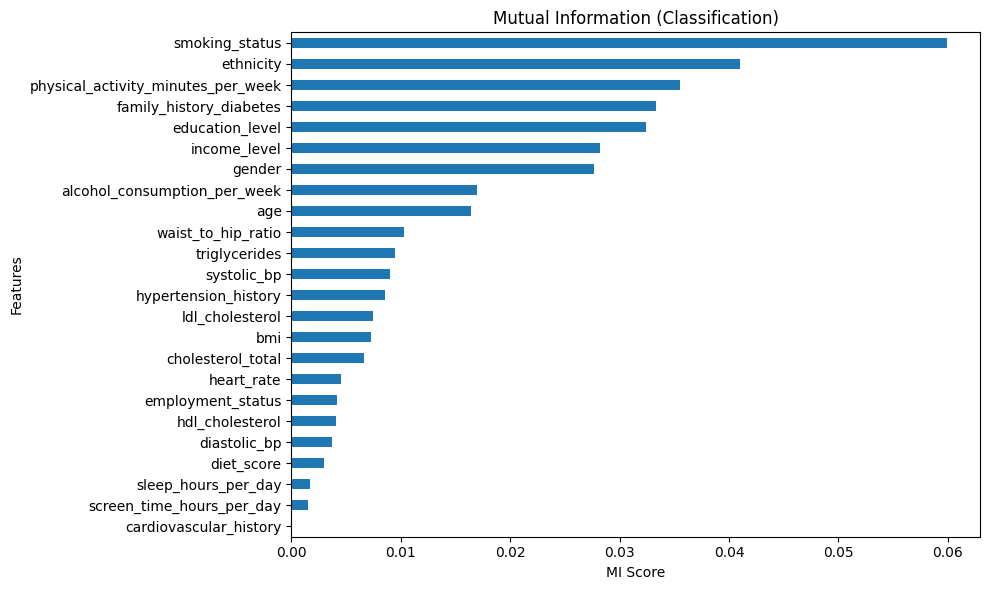

In [3]:
def mutual_information_classif(df, target, plot=True, figsize=(10, 6)):
    """
    Mutual Information for classification with automatic safe preprocessing.
    """

    X, y = _prepare_features_for_mi(df, target)

    mi = mutual_info_classif(X, y, discrete_features='auto')
    mi_series = (pd.Series(mi, index=X.columns).sort_values(ascending=True))
    
    if plot:
        plt.figure(figsize=figsize)
        mi_series.plot(kind="barh")
        plt.xlabel("MI Score")
        plt.ylabel("Features")
        plt.title("Mutual Information (Classification)")
        plt.tight_layout()
        plt.show()

mutual_information_classif(train, target)

## Heatmap Correlationship:

In [4]:
def overview(df, nunique_threshold=15):
    """
    Prints an overview of the DataFrame.
    - Ignores the last column (assumed target).
    - Counts numerical and categorical features.
    - Converts low-cardinality numeric features to categorical.
    """

    import pandas as pd

    # Drop last column (assumed target)
    features = df.iloc[:, :-1]

    # Initial type detection
    num_cols = features.select_dtypes(include=['int64', 'float64']).columns.tolist()
    cat_cols = features.select_dtypes(include=['object', 'category']).columns.tolist()

    # Convert low-cardinality numeric columns to categorical
    converted_cols = []
    for col in num_cols.copy():
        if features[col].nunique() <= nunique_threshold:
            df[col] = df[col].astype('category')
            num_cols.remove(col)
            cat_cols.append(col)
            converted_cols.append(col)

    print("===== DATA OVERVIEW =====")
    print(f"Total features (excluding last column): {features.shape[1]}")
    print(f"Numeric features: {len(num_cols)}")
    print(f"Categorical features: {len(cat_cols)}")

    if converted_cols:
        print(f"\nConverted to categorical (nunique ≤ {nunique_threshold}):")
        for col in converted_cols:
            print(f"  - {col}")

    print("\n--- Categorical Columns Detail ---")
    for col in cat_cols:
        print(f"{col}: {df[col].nunique()} unique values")

    return num_cols, cat_cols

num_cols, cat_cols = overview(train)

===== DATA OVERVIEW =====
Total features (excluding last column): 24
Numeric features: 14
Categorical features: 10

Converted to categorical (nunique ≤ 15):
  - alcohol_consumption_per_week
  - family_history_diabetes
  - hypertension_history
  - cardiovascular_history

--- Categorical Columns Detail ---
gender: 3 unique values
ethnicity: 5 unique values
education_level: 4 unique values
income_level: 5 unique values
smoking_status: 3 unique values
employment_status: 4 unique values
alcohol_consumption_per_week: 9 unique values
family_history_diabetes: 2 unique values
hypertension_history: 2 unique values
cardiovascular_history: 2 unique values


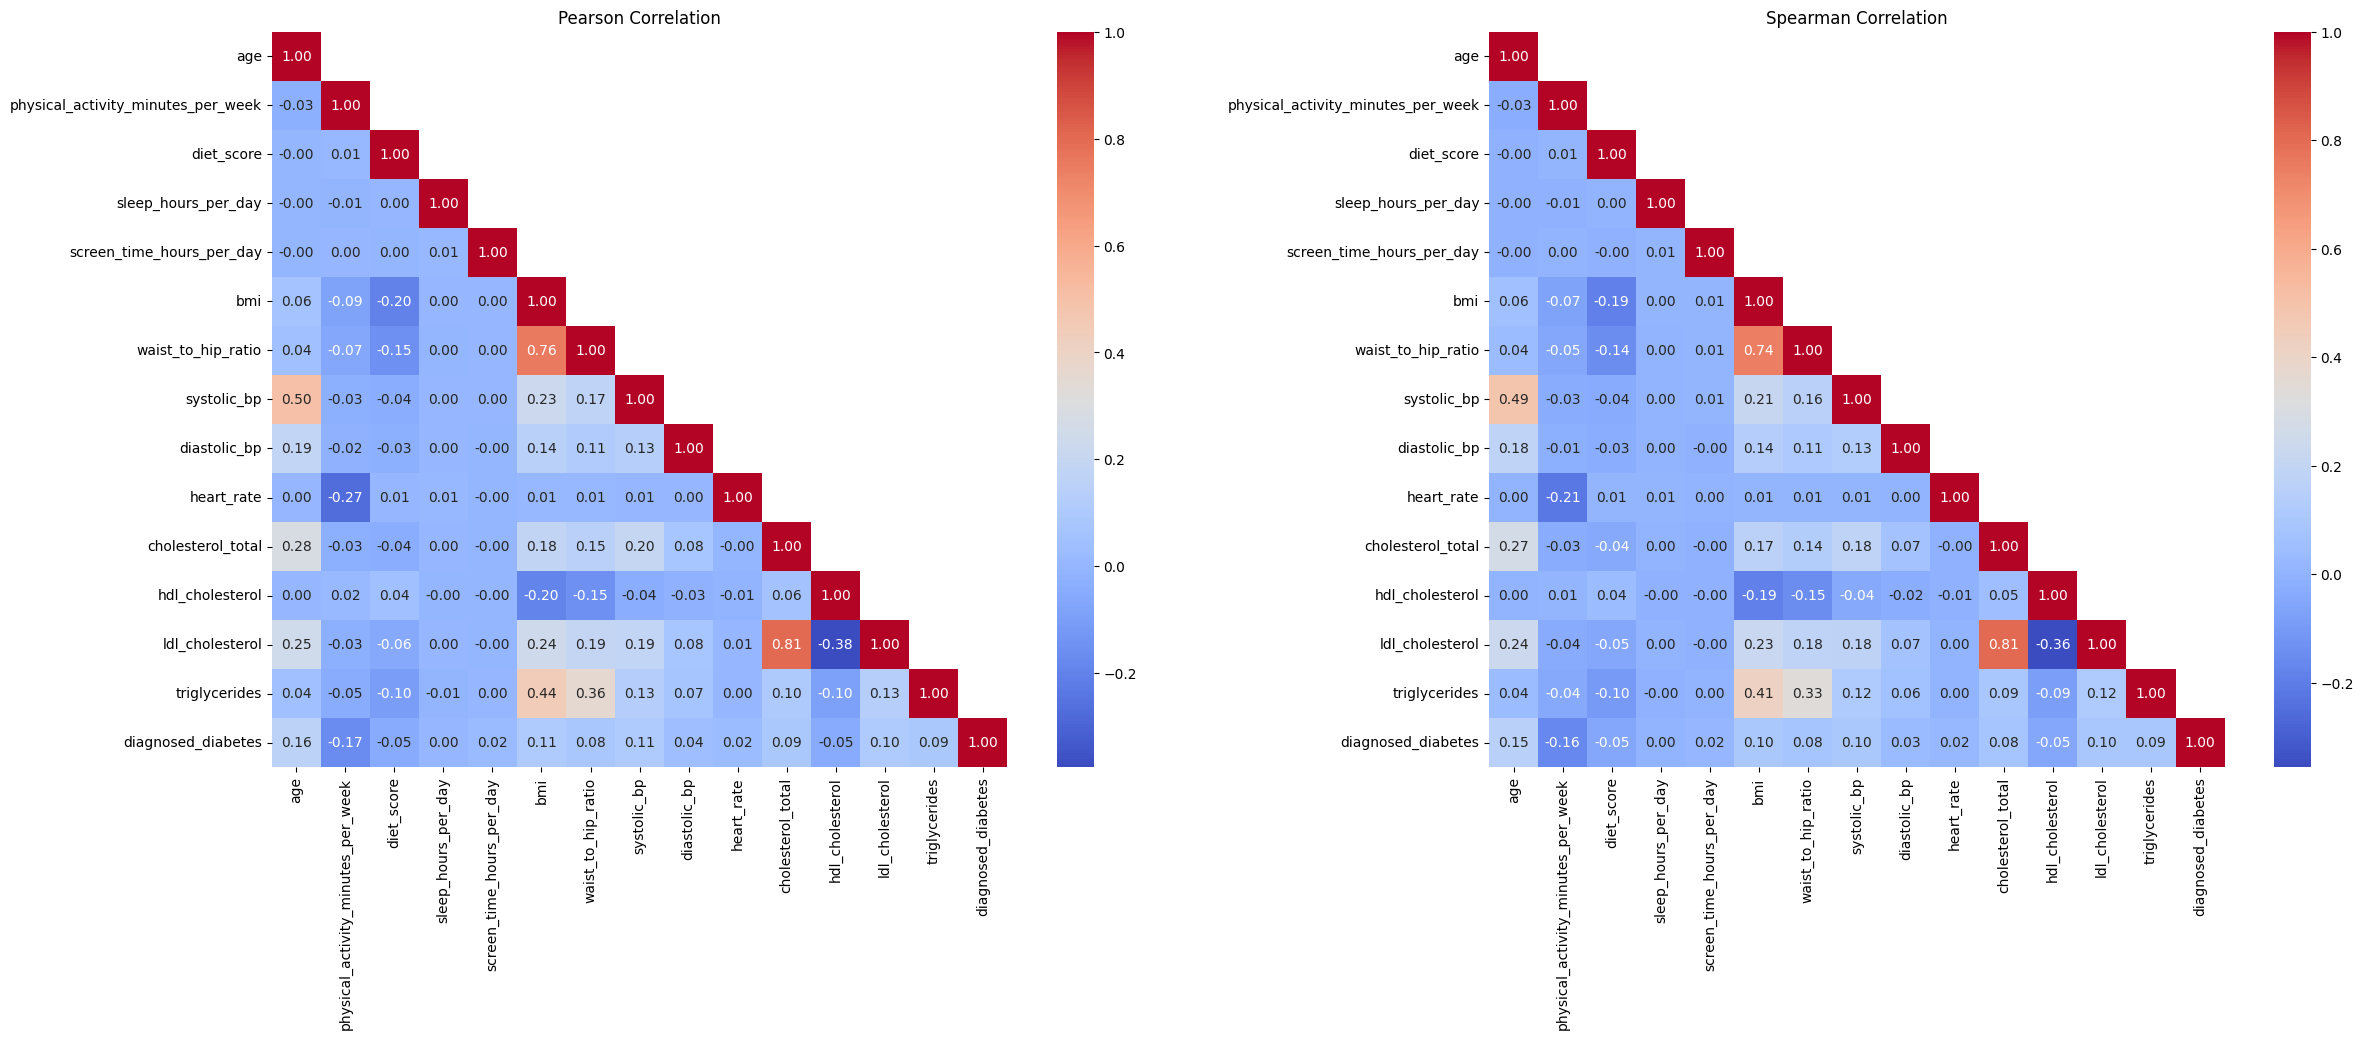

In [5]:
def plot_corr_heatmaps(df, figsize=(16, 6),
                       cmap='coolwarm', fmt='.2f', annot=True,
                       pearson_title='Pearson Correlation',
                       spearman_title='Spearman Correlation'):
    """
    Plots side-by-side correlation heatmaps (Pearson + Spearman) showing only the upper triangle.
    
    Parameters
    ----------
    df : pandas.DataFrame
    Input dataframe.
    figsize : tuple, default (16, 6)
    Figure size.
    cmap : str, default 'coolwarm'
    Colormap for heatmaps.
    pearson_title : str
    Title for Pearson subplot.
    spearman_title : str
    Title for Spearman subplot.
    """
    # Filter numeric columns only
    df = df.select_dtypes(include=[np.number])

    # Compute correlations
    corr_pearson = df.corr(method='pearson')
    corr_spearman = df.corr(method='spearman')

    # Lower triangle mask
    mask = np.tril(np.ones_like(corr_pearson, dtype=bool))

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    sns.heatmap(
        corr_pearson, mask=~mask, annot=annot, fmt=fmt,
        cmap=cmap, square=True, cbar=True, ax=axes[0]
    )
    axes[0].set_title(pearson_title)

    sns.heatmap(
        corr_spearman, mask=~mask, annot=annot, fmt=fmt,
        cmap=cmap, square=True, cbar=True, ax=axes[1]
    )
    axes[1].set_title(spearman_title)

    plt.tight_layout()
    plt.show()
plot_corr_heatmaps(train,figsize = (25,10))

Feature have high coefficient:

* bmi - waist to hip ratio
* cholesterol total - ldl cholesterol
* systolic bp - age
* hdl vs ldl cholesterol

## EDA numerical features vs target:

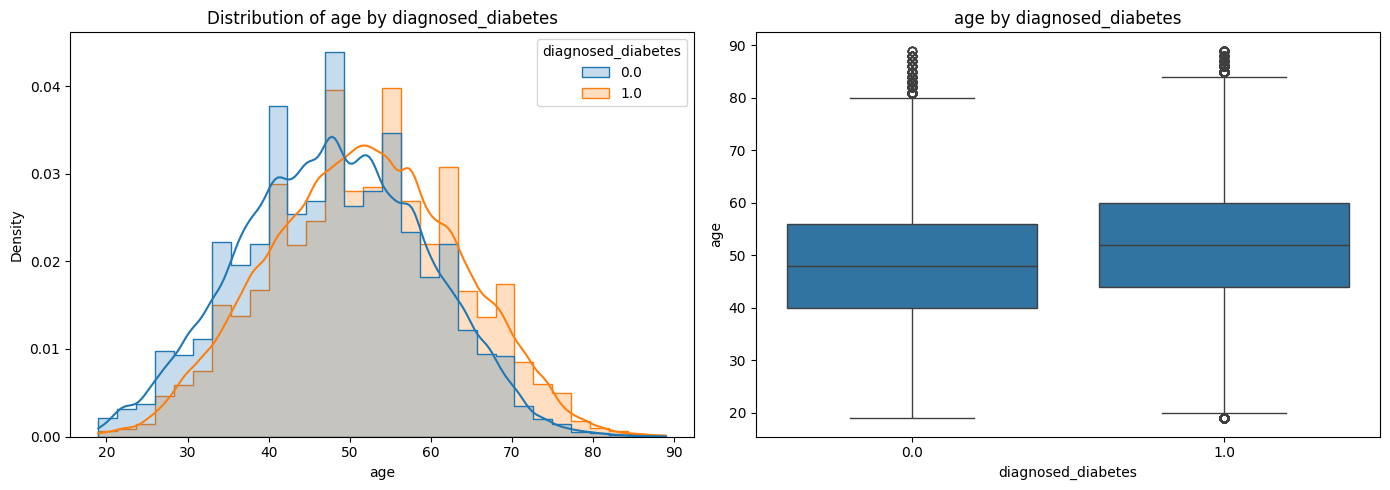

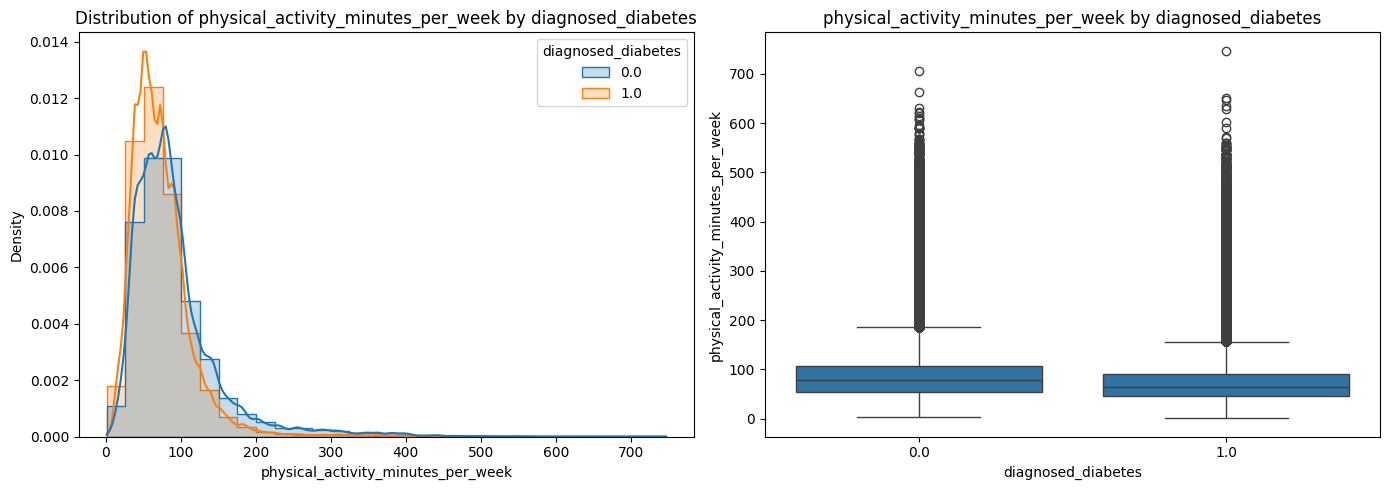

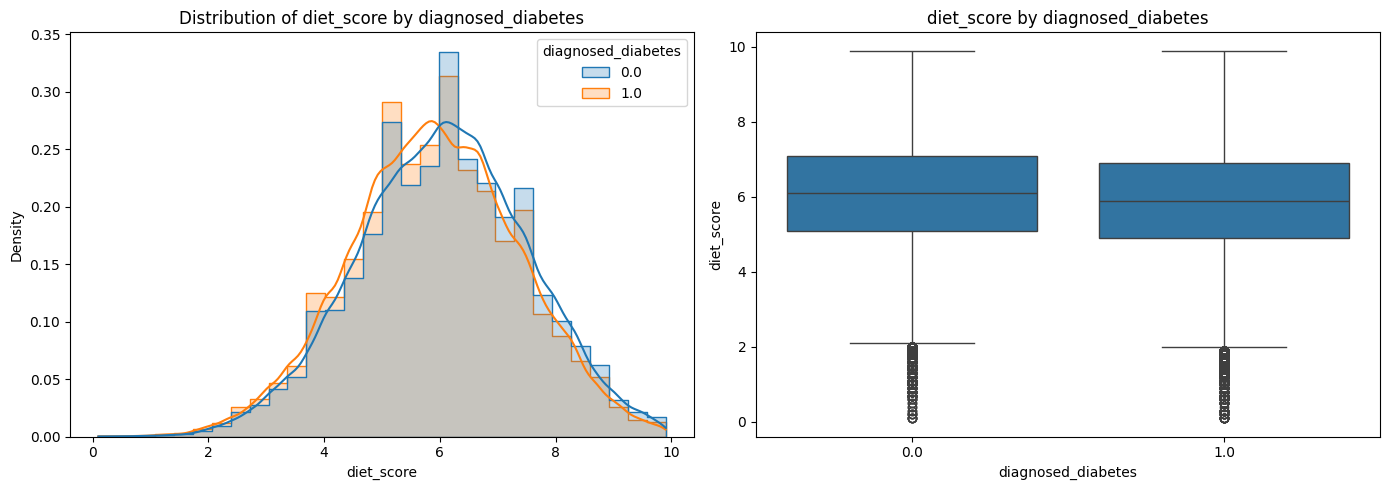

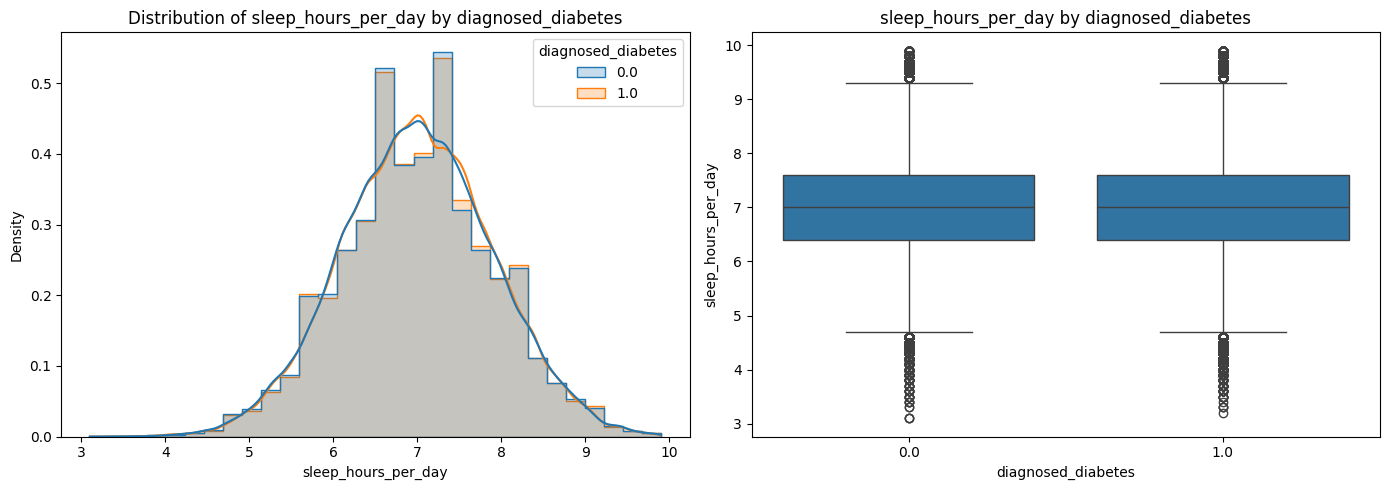

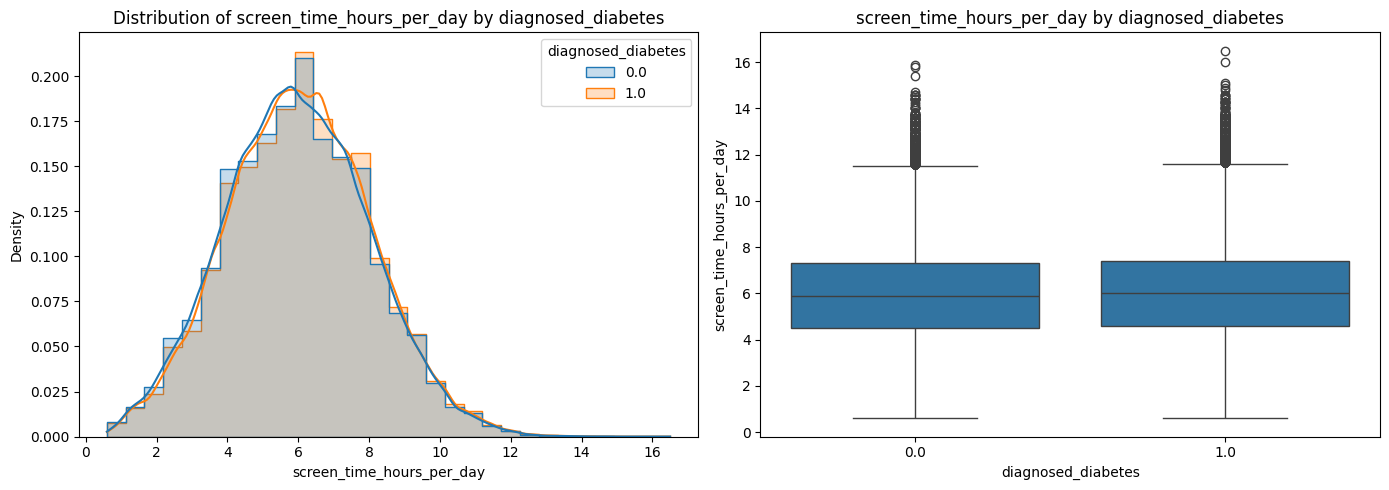

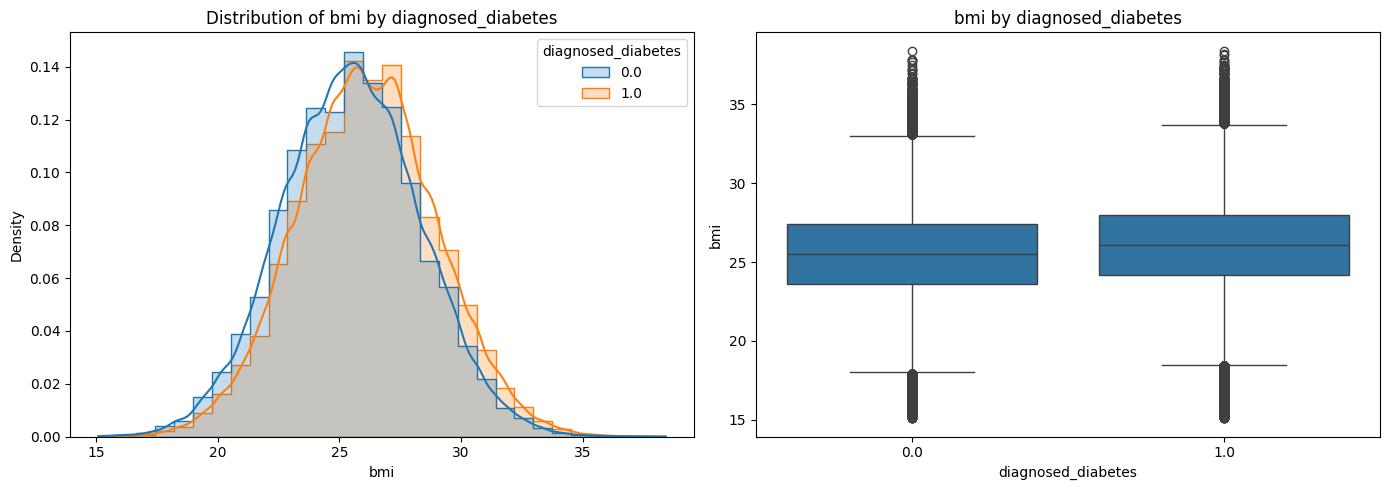

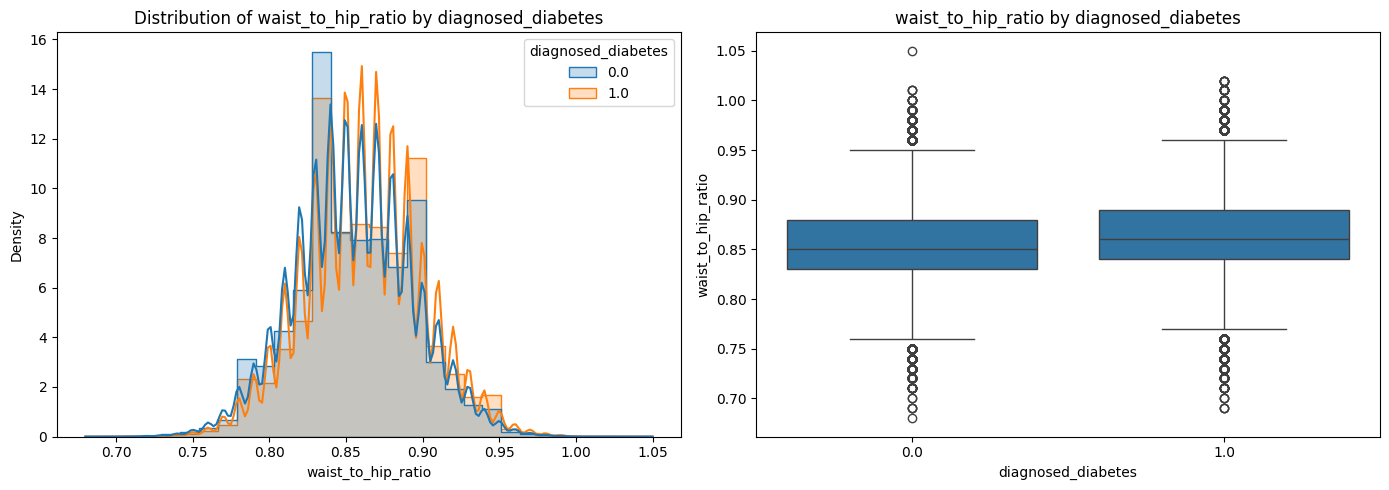

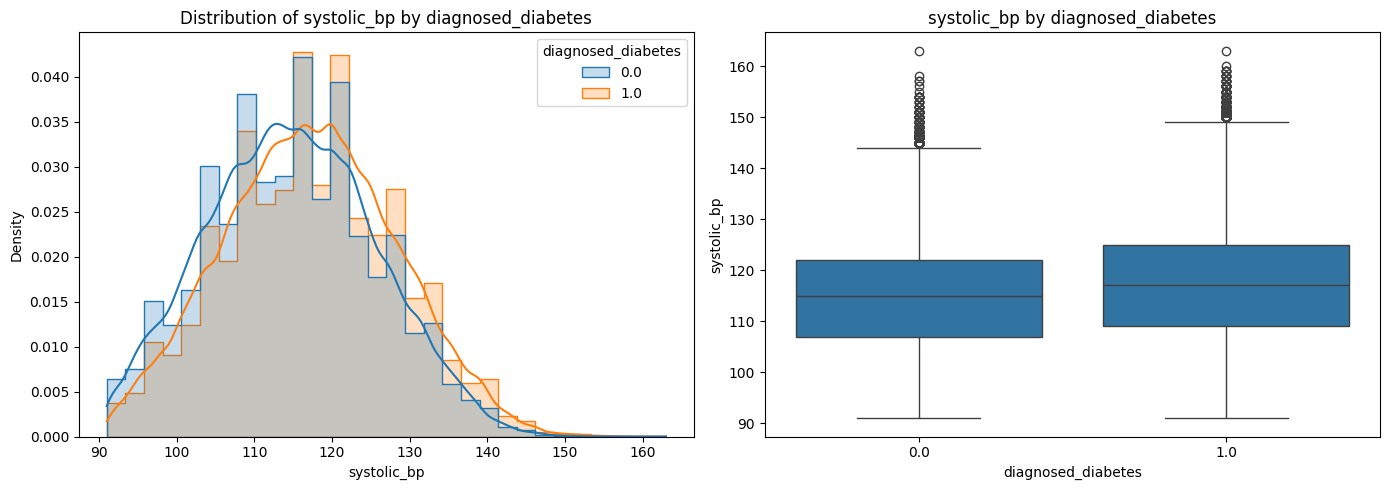

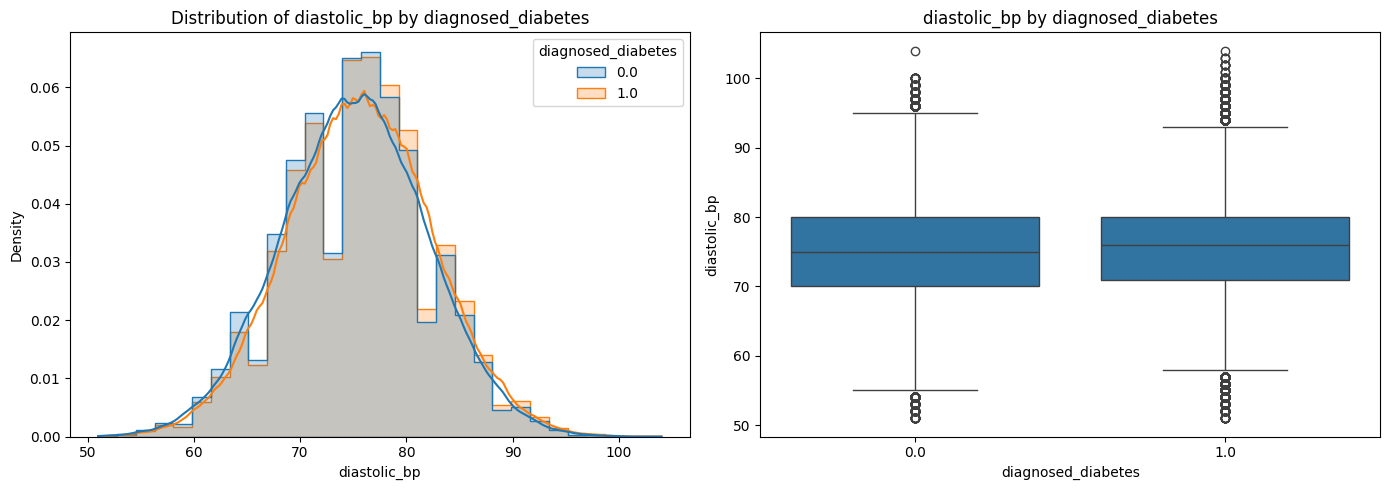

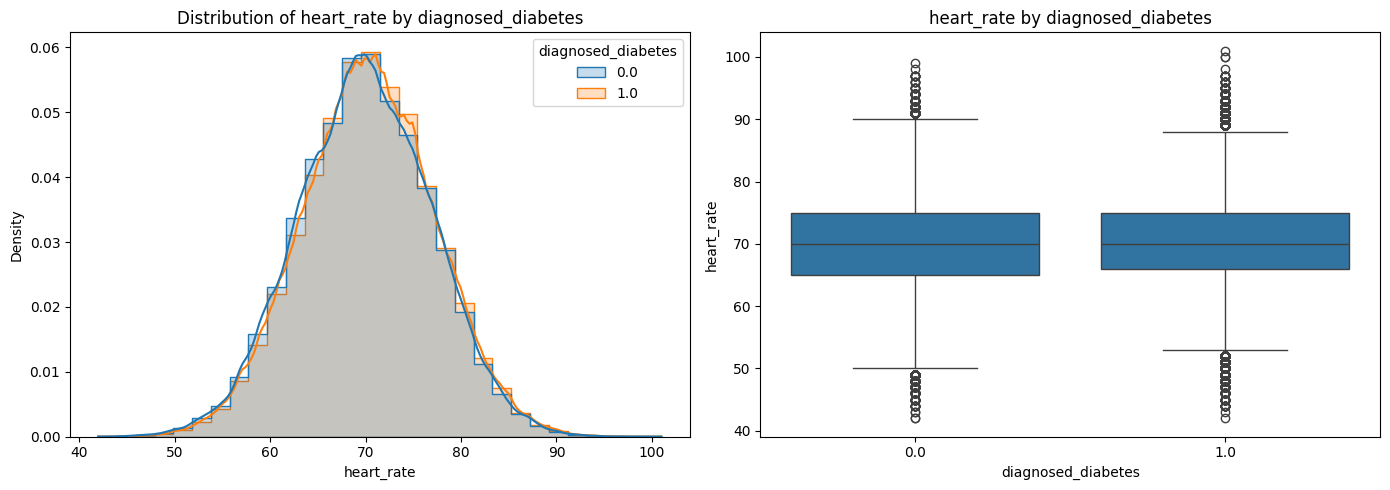

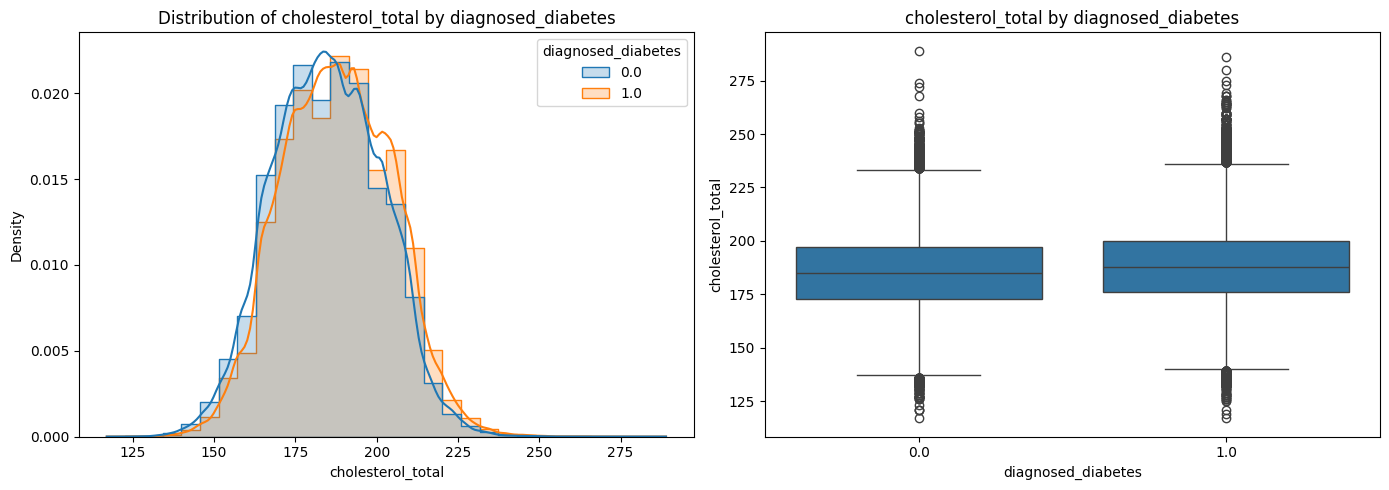

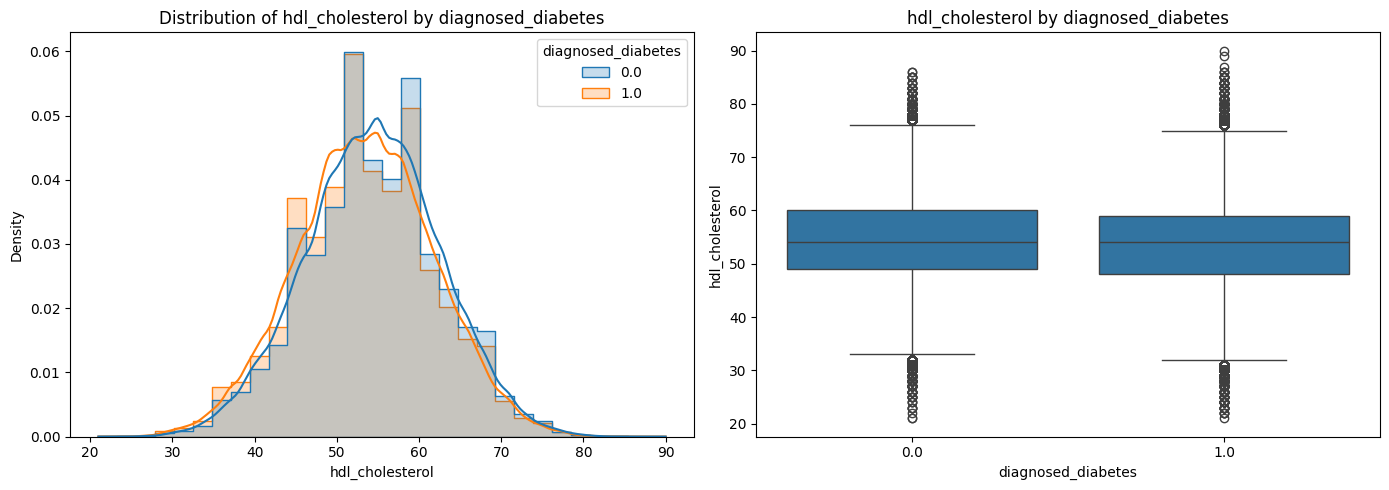

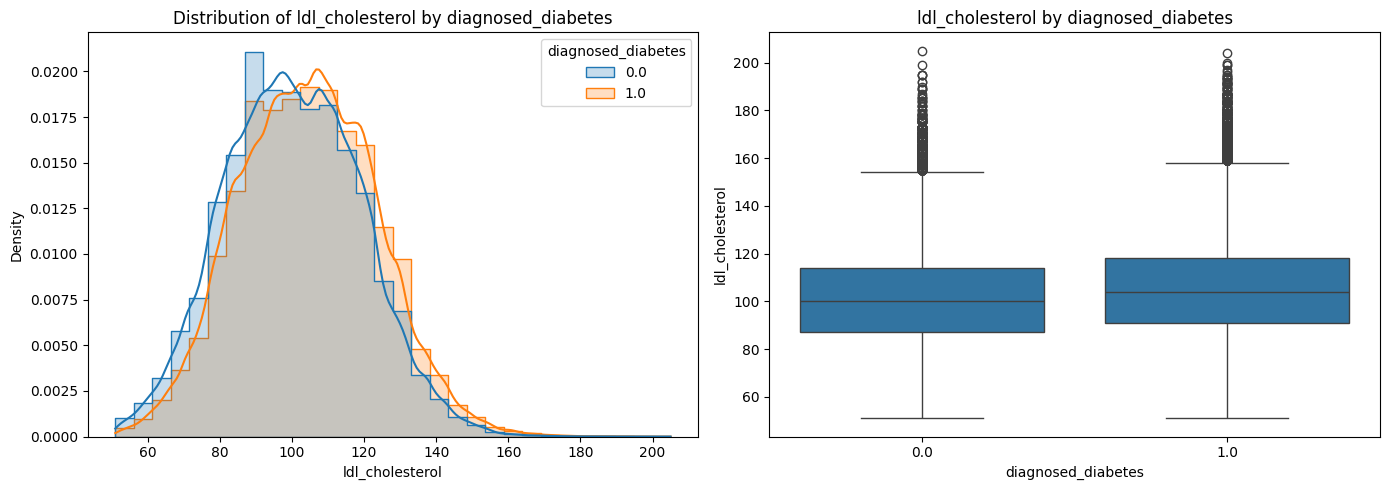

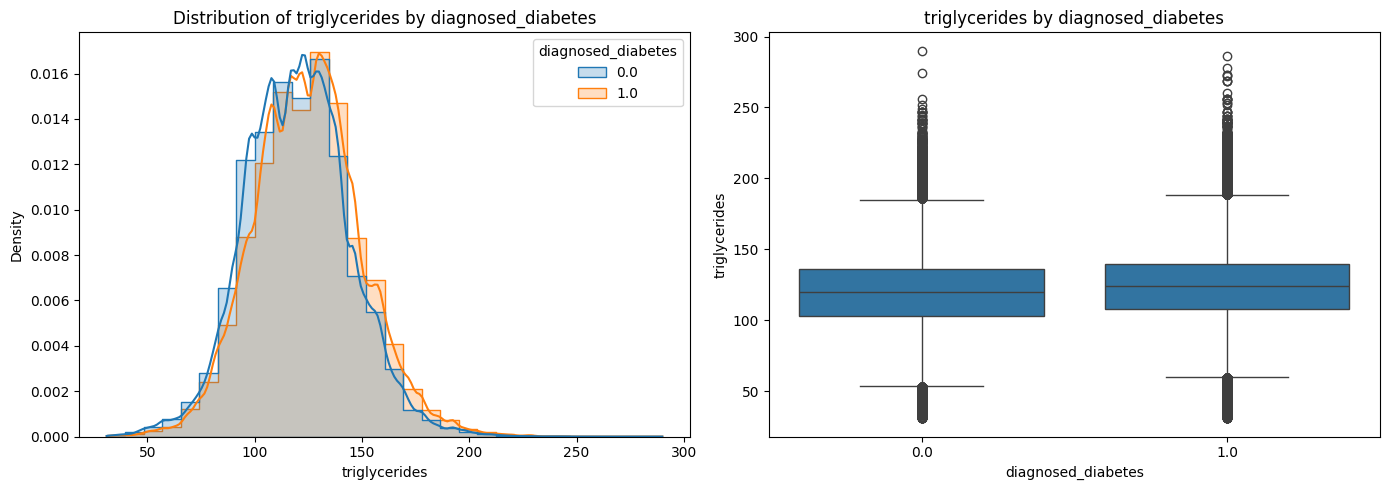

In [6]:
def plot_num_vs_target(df, target, bins=30):
    """
    Generate distribution plots for numerical features grouped by target.

    For each numerical column (excluding the target), this function creates
    side-by-side plots:
      1. Histogram with hue=target
      2. Boxplot grouped by target

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe containing features and the target.
    target : str
        Target variable used as hue / grouping.
    bins : int, default=30
        Number of histogram bins.

    Returns
    -------
    None
        Displays matplotlib plots.
    """
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns

    for col in num_cols:
        if col == target:
            continue

        fig, ax = plt.subplots(1, 2, figsize=(14, 5))

        # Histogram with hue = target
        sns.histplot(
            data=df,
            x=col,
            hue=target,
            bins=bins,
            kde=True,
            element="step",stat="density",
            common_norm=False,
            ax=ax[0]
        )
        ax[0].set_title(f"Distribution of {col} by {target}")

        # Boxplot by target
        sns.boxplot(
            data=df,
            x=target,
            y=col,
            ax=ax[1]
        )
        ax[1].set_title(f"{col} by {target}")

        plt.tight_layout()
        plt.show()
plot_num_vs_target(train,target)

## EDA categorical features vs target:

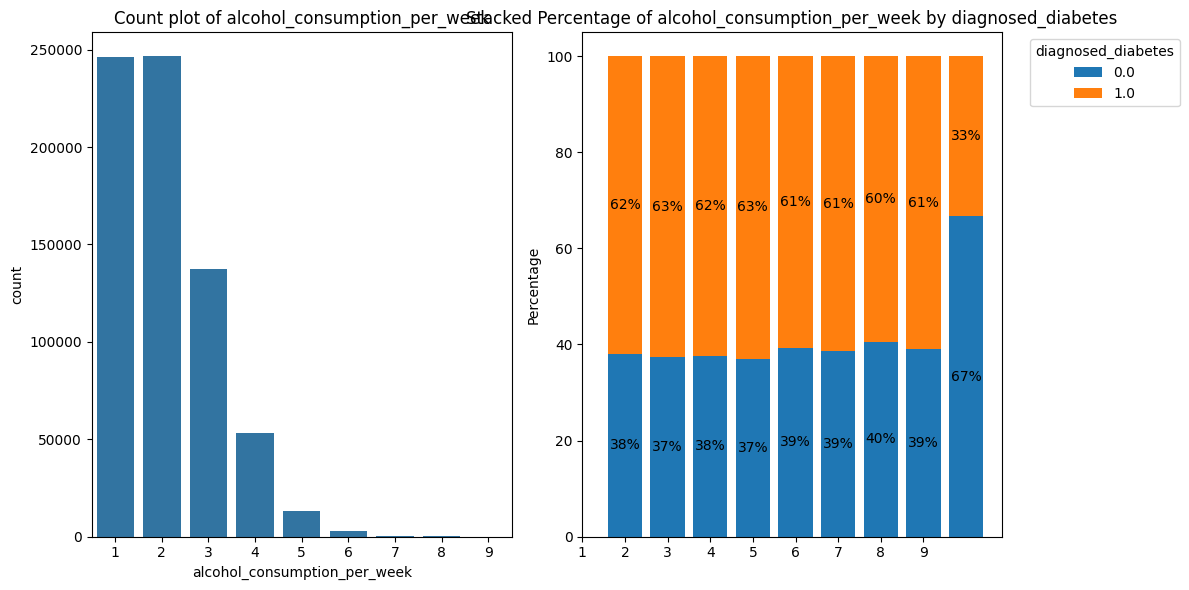

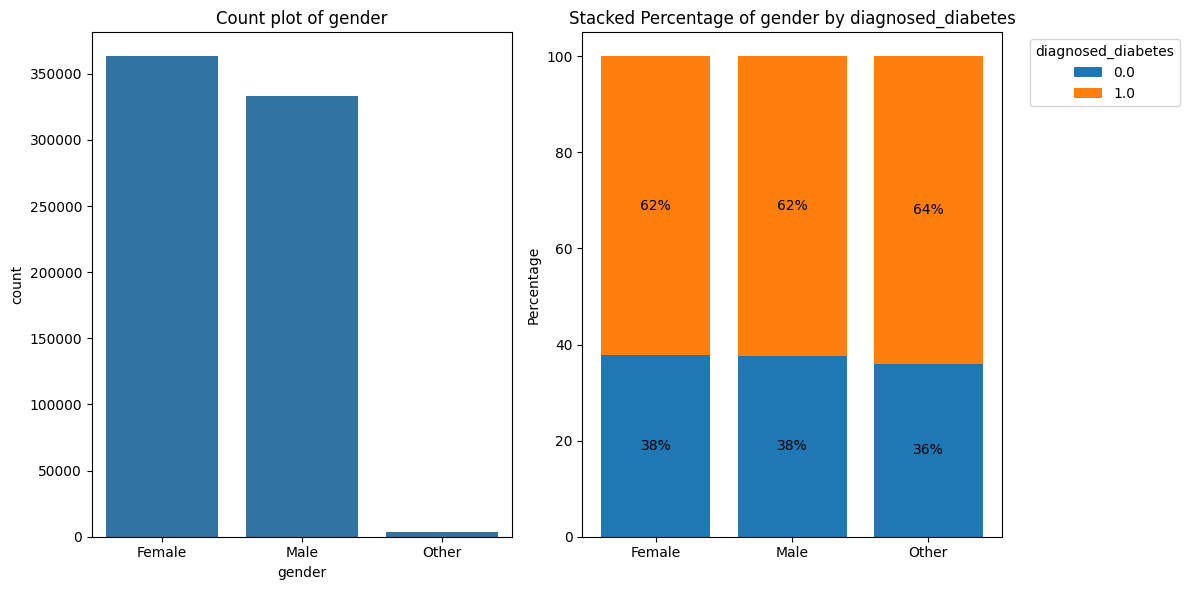

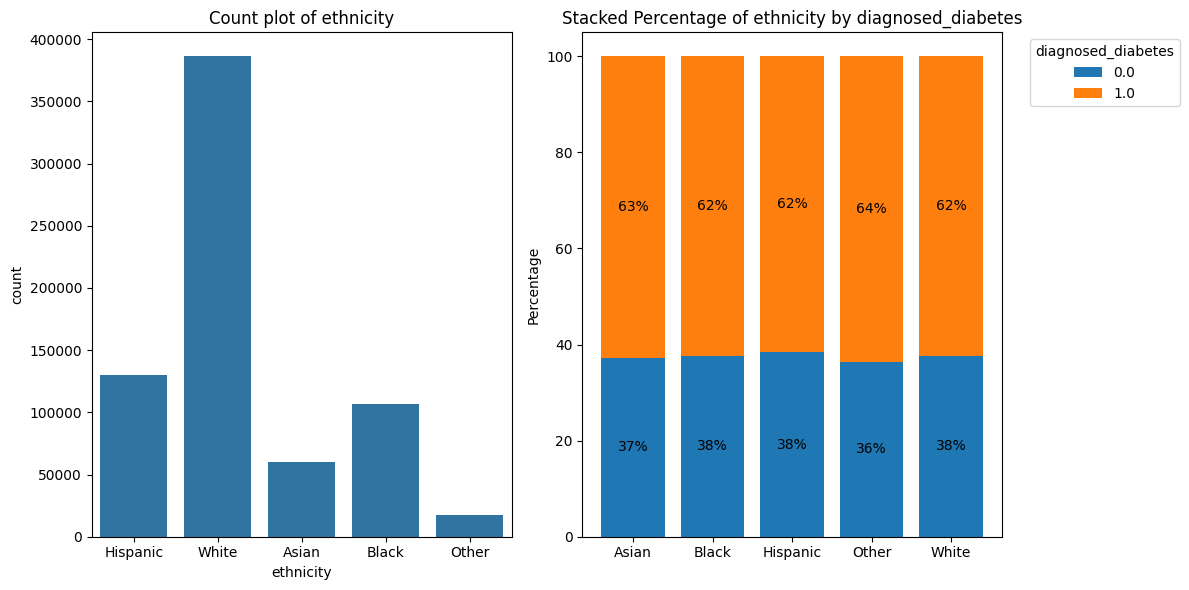

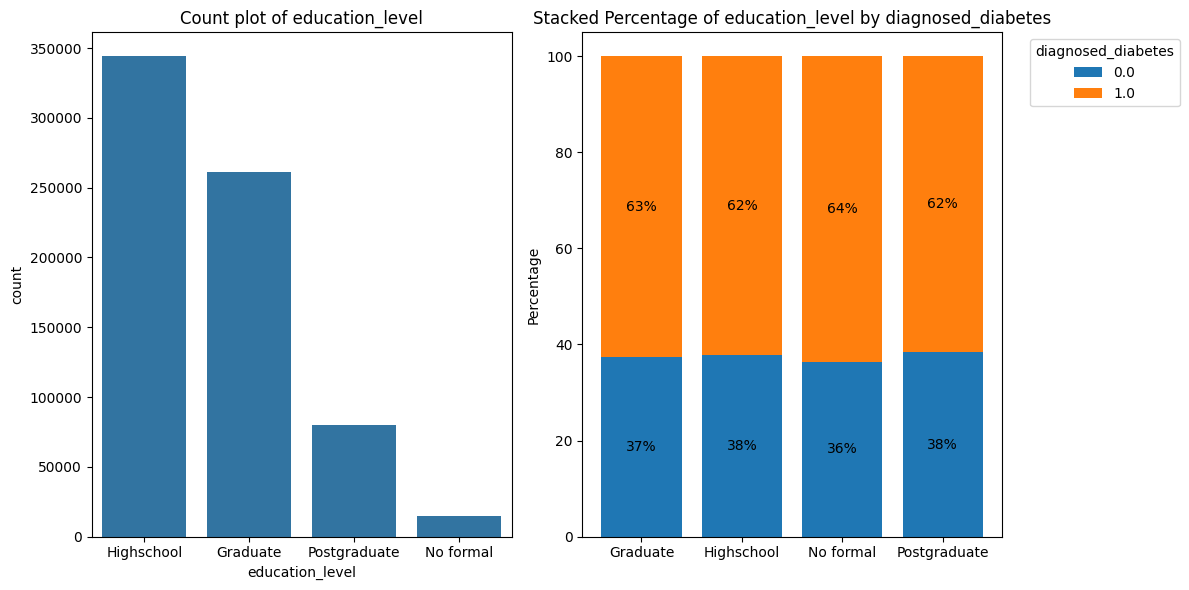

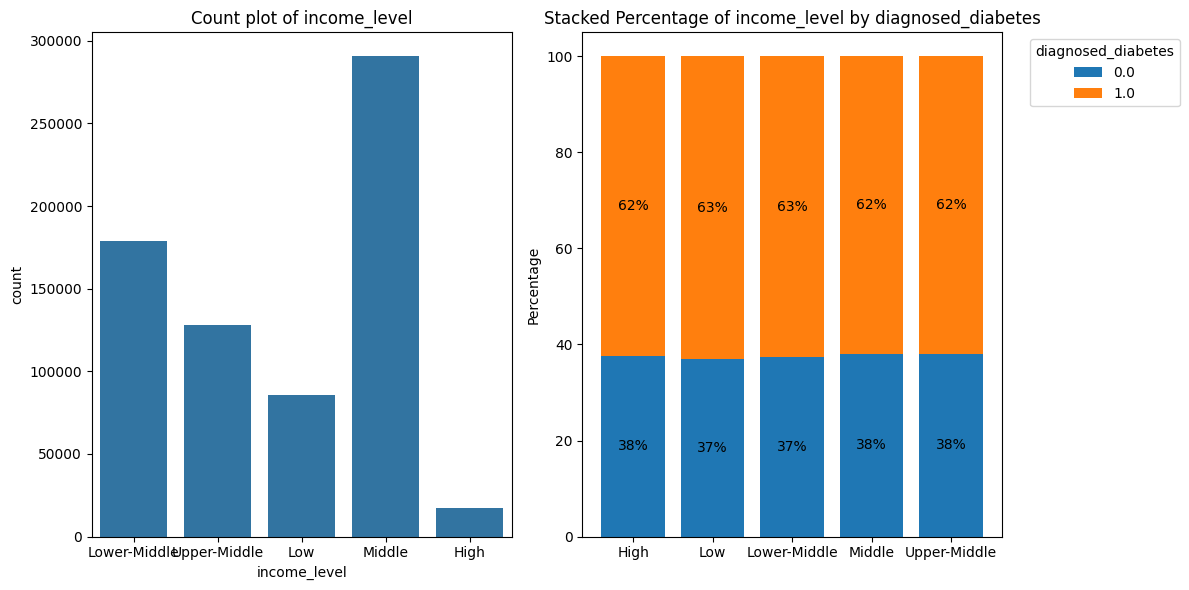

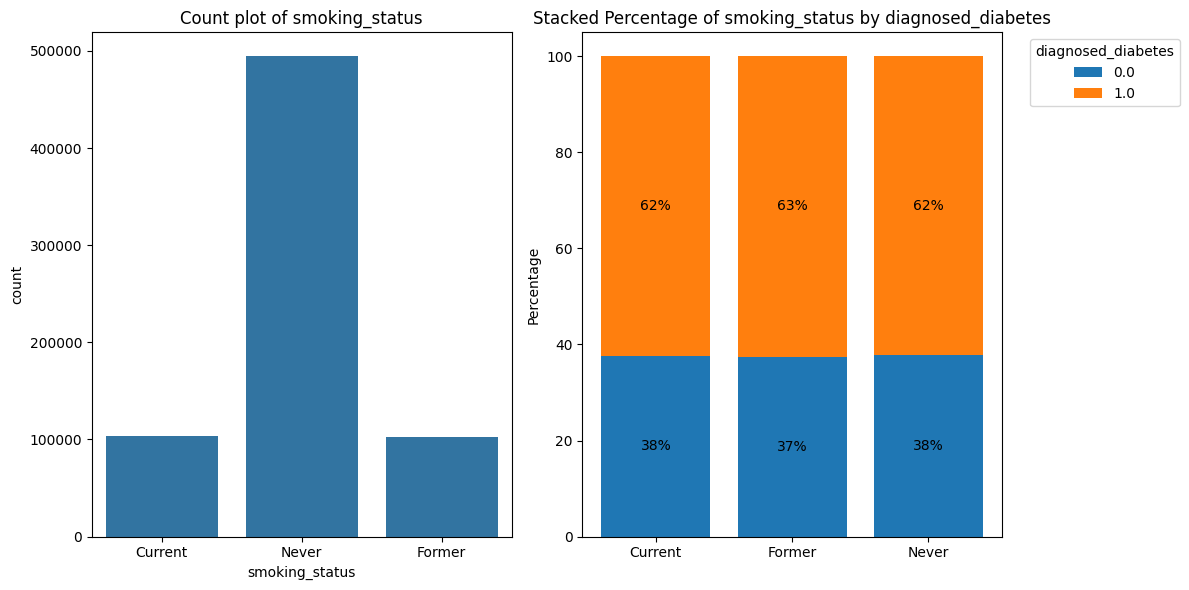

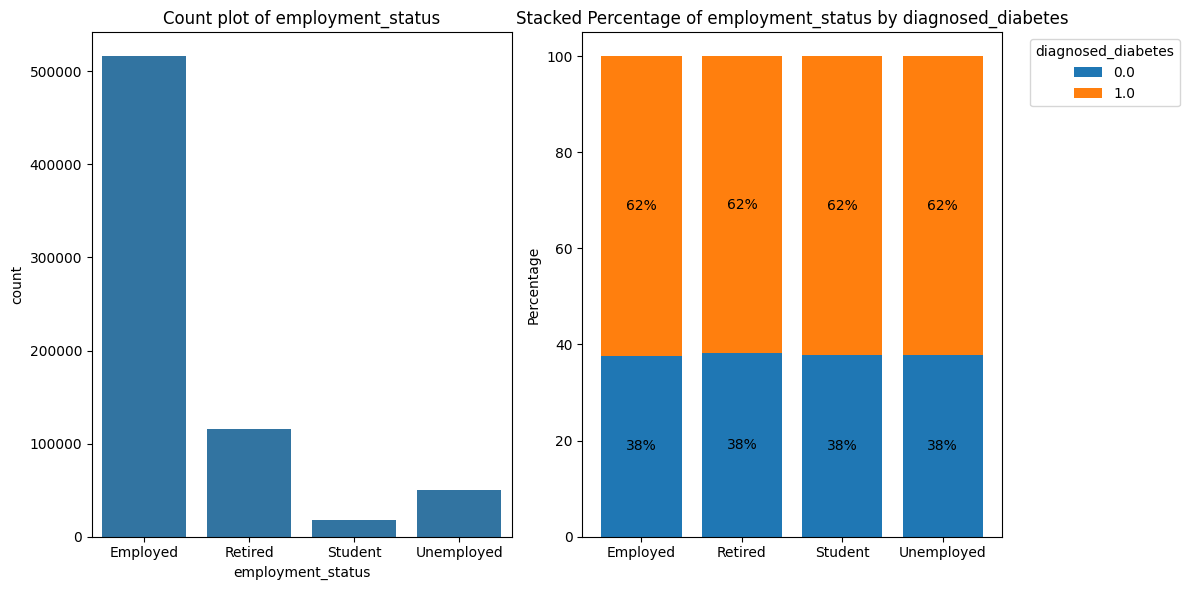

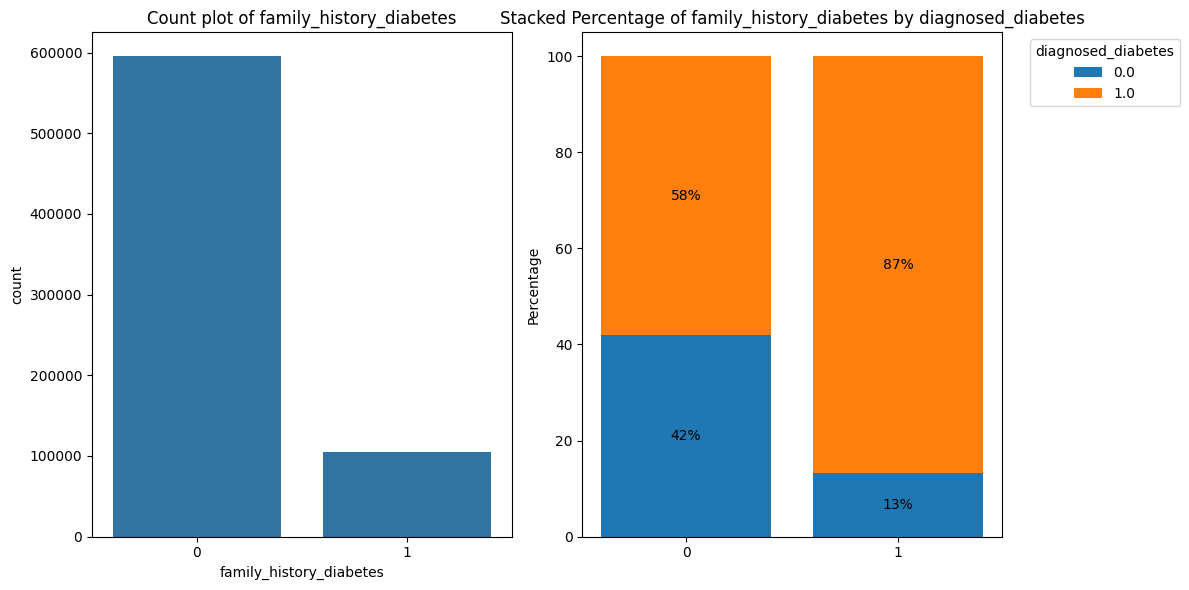

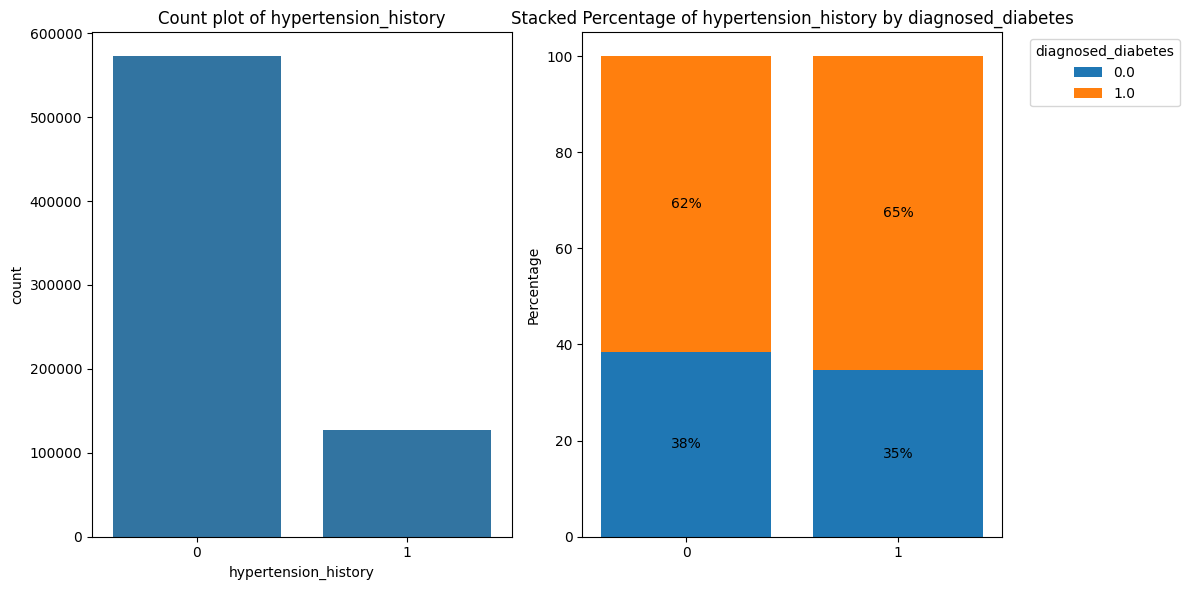

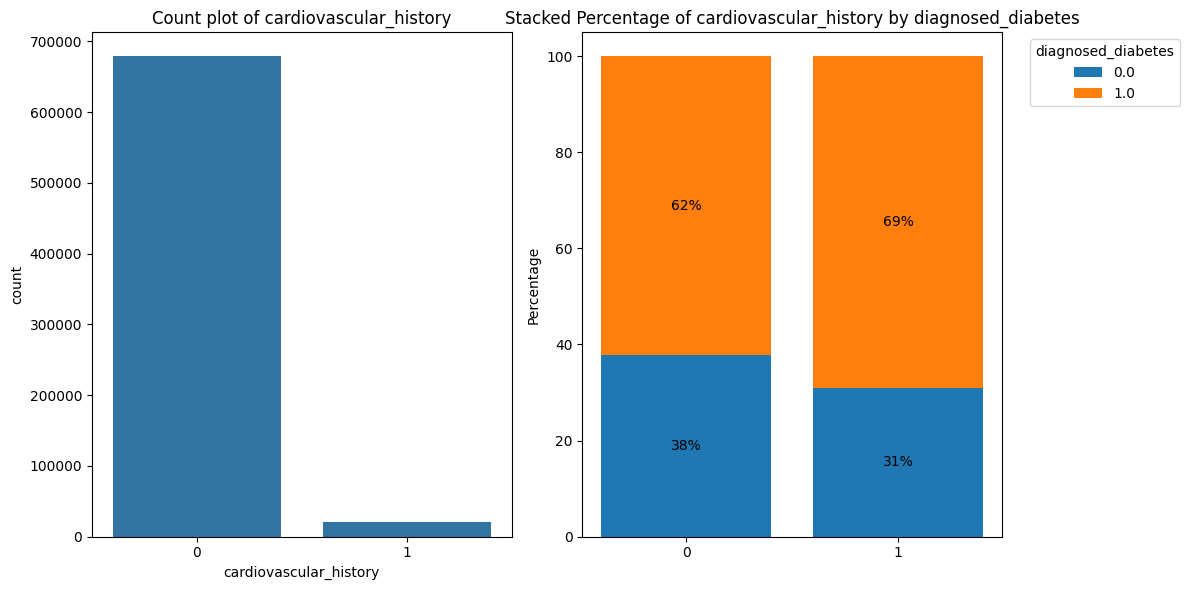

In [7]:
def plot_cat_vs_target(df, target, max_unique=20):
    """
    Generate count plots and stacked percentage bar charts for all categorical features
    (with limited unique values) against a target variable.

    This function iterates through each column in the dataframe, identifies
    categorical-like features based on the number of unique values (`max_unique`),
    and for each valid feature produces two side-by-side visualizations:

    1. Count Plot – Shows the distribution of categories.
    2. Stacked Percentage Bar Chart – Displays the percentage breakdown of the target
       variable within each category of the feature.

    Percentages are annotated inside each bar segment for improved interpretability.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe containing features and the target.
    target : str
        The name of the target variable to compare against categorical features.
    max_unique : int, default=20
        Maximum allowed number of unique values in a column to be treated as
        categorical for plotting. Columns exceeding this threshold are skipped.

    Returns
    -------
    None
        Displays matplotlib plots for each eligible categorical feature.
    """
    for col in df.columns:
        if col == target:
            continue
        if df[col].nunique() <= max_unique:
            fig, ax = plt.subplots(1, 2, figsize=(12, 6))
            sns.countplot(x=col, data=df, ax=ax[0])
            ax[0].set_title(f"Count plot of {col}")
            crosstab = pd.crosstab(df[col], df[target], normalize='index') * 100
            bottom = pd.Series(0, index=crosstab.index)
            for category in crosstab.columns:
                ax[1].bar(crosstab.index, crosstab[category], bottom=bottom, label=f"{category}")
                for idx, value in enumerate(crosstab[category]):
                    if value > 0:
                        ax[1].text(
                            crosstab.index[idx],
                            bottom.iloc[idx] + value / 2,
                            f"{value:.0f}%",
                            ha='center', va='center'
                        )
                bottom += crosstab[category].values
            ax[1].set_title(f"Stacked Percentage of {col} by {target}")
            ax[1].set_ylabel("Percentage")
            ax[1].legend(title=target, bbox_to_anchor=(1.05, 1), loc='upper left')
            ax[1].set_xticks(range(len(crosstab.index)))
            ax[1].set_xticklabels(crosstab.index)
            plt.tight_layout()
            plt.show()
plot_cat_vs_target(train,target)


# Feature Engineering:
## BMI - Waist to hip ratio:

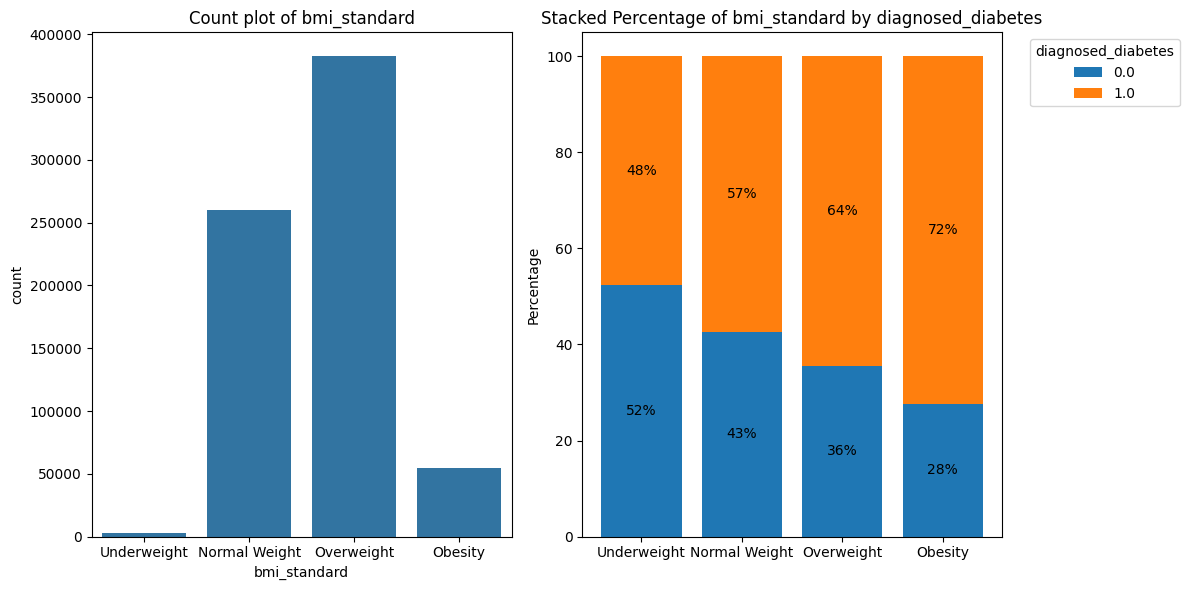

In [8]:
def bmi_standards(df):
    """
    Classify BMI according to WHO standards and add an ordinal categorical column 'bmi_who'.
    
    Order:
    Underweight < Normal Weight < Overweight < Obesity
    """
    
    conditions = [
        df['bmi'] < 18.5,
        (df['bmi'] >= 18.5) & (df['bmi'] < 25.0),
        (df['bmi'] >= 25.0) & (df['bmi'] < 30.0),
        df['bmi'] >= 30.0]
    
    categories = [
        'Underweight',
        'Normal Weight',
        'Overweight',
        'Obesity']
    
    df['bmi_standard'] = np.select(conditions, categories, default=None)
    
    # Define ordered categorical type
    bmi_cat_type = pd.CategoricalDtype(
        categories=categories,
        ordered=True)
    
    # Convert to ordinal categorical
    df['bmi_standard'] = df['bmi_standard'].astype(bmi_cat_type)
    
    return df

train = bmi_standards(train)
test = bmi_standards(test)
plot_cat_vs_target(train[['bmi_standard',target]], target, max_unique=20)

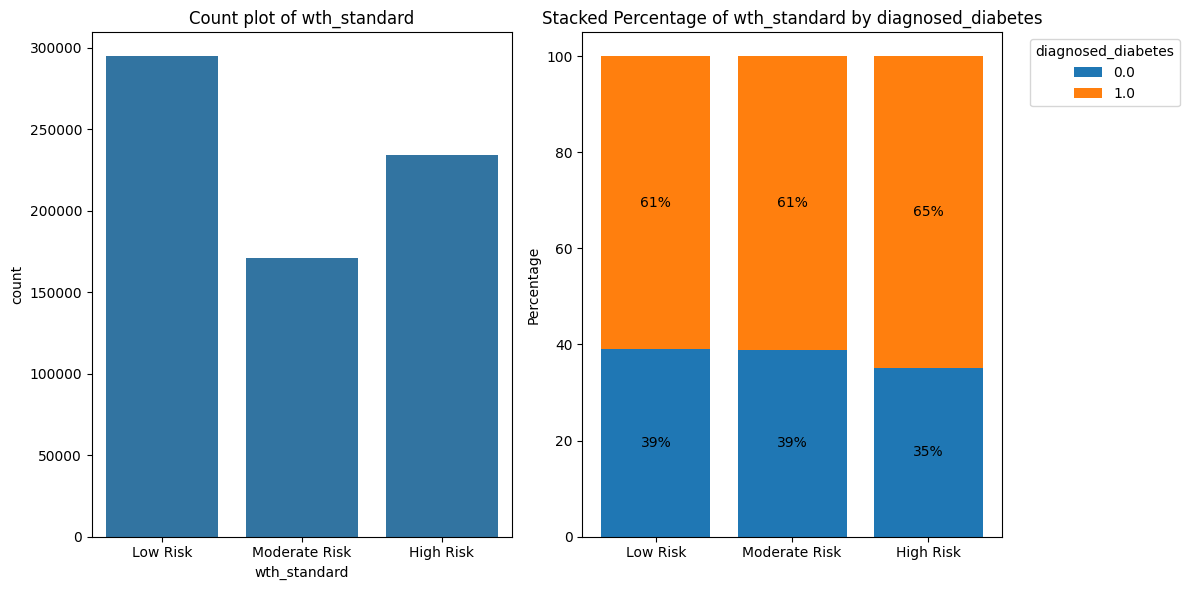

In [9]:
def wth_standard(df):
    """
    Classify waist-to-hip ratio (WHR) risk based on WHO standards.
    Treat 'Other' as 'Female'.
    """
    
    # Convert to string first to avoid categorical replace warning
    gender = df['gender'].astype(str)
    
    # Replace 'Other' with 'Female'
    gender = gender.replace({'Other': 'Female'})
    
    whr = df['waist_to_hip_ratio']
    
    conditions = [
        # Low Risk
        ((gender == 'Male') & (whr < 0.90)) |
        ((gender == 'Female') & (whr < 0.80)),
        
        # Moderate Risk
        ((gender == 'Male') & (whr >= 0.90) & (whr < 1.00)) |
        ((gender == 'Female') & (whr >= 0.80) & (whr < 0.85)),
        
        # High Risk
        ((gender == 'Male') & (whr >= 1.00)) |
        ((gender == 'Female') & (whr >= 0.85))
    ]
    
    categories = ['Low Risk', 'Moderate Risk', 'High Risk']
    
    df['wth_standard'] = np.select(conditions, categories, default=None)
    
    # Ordered categorical
    wth_cat_type = pd.CategoricalDtype(categories=categories, ordered=True)
    df['wth_standard'] = df['wth_standard'].astype(wth_cat_type)
    
    return df


train = wth_standard(train)
test = wth_standard(test)
plot_cat_vs_target(train[['wth_standard',target]], target, max_unique=20)

In [10]:
train['Risk_Weight_Combination'] = train['bmi_standard'].astype(str) + ' - ' + train['wth_standard'].astype(str)
test['Risk_Weight_Combination'] = test['bmi_standard'].astype(str) + ' - ' + test['wth_standard'].astype(str)
bmi_levels = train['bmi_standard'].cat.categories
wth_levels = train['wth_standard'].cat.categories

risk_weight_categories = [
    f"{bmi} - {wth}"
    for bmi in bmi_levels
    for wth in wth_levels]

# Convert to ordered categorical
train['Risk_Weight_Combination'] = pd.Categorical(
    train['Risk_Weight_Combination'],
    categories=risk_weight_categories)

test['Risk_Weight_Combination'] = pd.Categorical(
    test['Risk_Weight_Combination'],
    categories=risk_weight_categories)

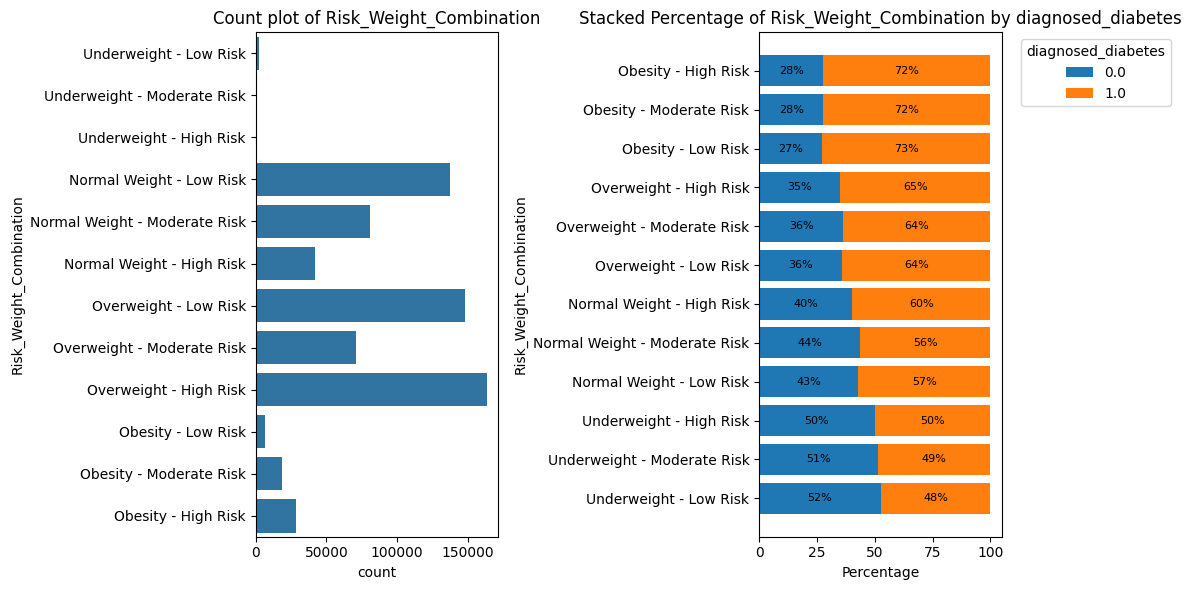

In [11]:
def plot_cat_vs_target_v2(df, y, max_unique=20):
    for col in df.columns:
        if col == y:
            continue
        if df[col].nunique() <= max_unique:
            fig, ax = plt.subplots(1, 2, figsize=(12, 6))
            
            # Count plot (still x=col)
            sns.countplot(y=col, data=df, ax=ax[0])
            ax[0].set_title(f"Count plot of {col}")
            
            # Stacked percentage bar chart (y=col)
            crosstab = pd.crosstab(df[col], df[y], normalize='index') * 100
            bottom = pd.Series(0, index=crosstab.index)
            for category in crosstab.columns:
                ax[1].barh(crosstab.index, crosstab[category], left=bottom, label=f"{category}")
                for idx, value in enumerate(crosstab[category]):
                    if value > 0:
                        ax[1].text(
                            bottom.iloc[idx] + value / 2,
                            crosstab.index[idx],
                            f"{value:.0f}%",
                            ha='center', va='center',
                            fontsize=8
                        )
                bottom += crosstab[category].values
            
            ax[1].set_title(f"Stacked Percentage of {col} by {y}")
            ax[1].set_xlabel("Percentage")
            ax[1].set_ylabel(f"{col}")
            ax[1].legend(title=y, bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.tight_layout()
            plt.show()

plot_cat_vs_target_v2(train[['Risk_Weight_Combination',target]], target, max_unique=20)

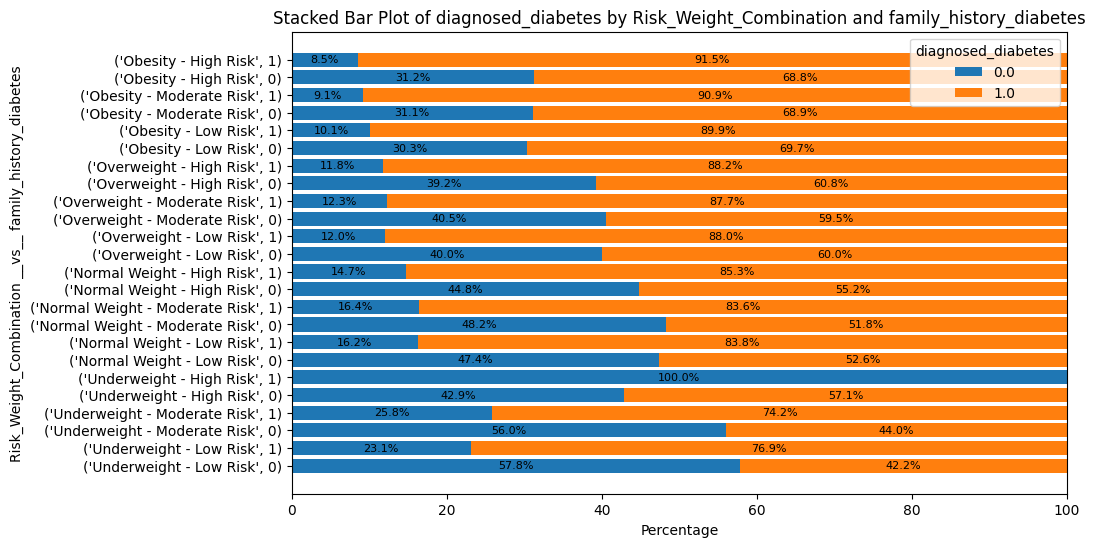

In [12]:
def EDA_stacked_depression_v2(df, col_1, col_2, target, ax=None):
    grouped_data = (
        df.groupby([col_1, col_2])[target]
        .value_counts(normalize=True)
        .mul(100)
        .to_frame("Percentage")
        .reset_index()
    )

    pivot_data = grouped_data.pivot_table(
        index=[col_1, col_2],
        columns=target,
        values="Percentage",
        fill_value=0
    )

    # Create figure/axes only if none is provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    left_values = pd.Series(0, index=pivot_data.index)

    for depression_level in pivot_data.columns:
        bars = ax.barh(
            range(len(pivot_data.index)),
            pivot_data[depression_level],
            left=left_values,
            label=depression_level
        )

        for bar, (_, row) in zip(bars, pivot_data.iterrows()):
            width = bar.get_width()
            if width > 0:
                ax.text(
                    bar.get_x() + width / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f"{width:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=8
                )

        left_values += pivot_data[depression_level]

    ax.set_title(f"Stacked Bar Plot of {target} by {col_1} and {col_2}")
    ax.set_xlabel("Percentage")
    ax.set_ylabel(f"{col_1} __vs__ {col_2}")
    ax.legend(title=target)
    ax.set_yticks(range(len(pivot_data.index)))
    ax.set_yticklabels(pivot_data.index)

    # Only show the plot if this function created the figure
    if ax is None:
        plt.tight_layout()
        plt.show()

EDA_stacked_depression_v2(
    train,
    'Risk_Weight_Combination',
    'family_history_diabetes',
    target)        

Looking at the distribution, it seems that the combination of BMI and WHR doesn't provide much insight. However, when we combine them with a family history of diabetes, the difference becomes clear. Patients who are overweight or obese and have a family history of diabetes have a significantly higher chance of developing the condition

## Blood Pressure:
```python
IF systolic ≥ 180 OR diastolic ≥ 110:
    Grade 3 Hypertension
ELSE IF systolic ≥ 160 OR diastolic ≥ 100:
    Grade 2 Hypertension
ELSE IF systolic ≥ 140 OR diastolic ≥ 90:
    Grade 1 Hypertension
ELSE IF systolic 130–139 OR diastolic 85–89:
    Normal–High
ELSE:
    Normal
```

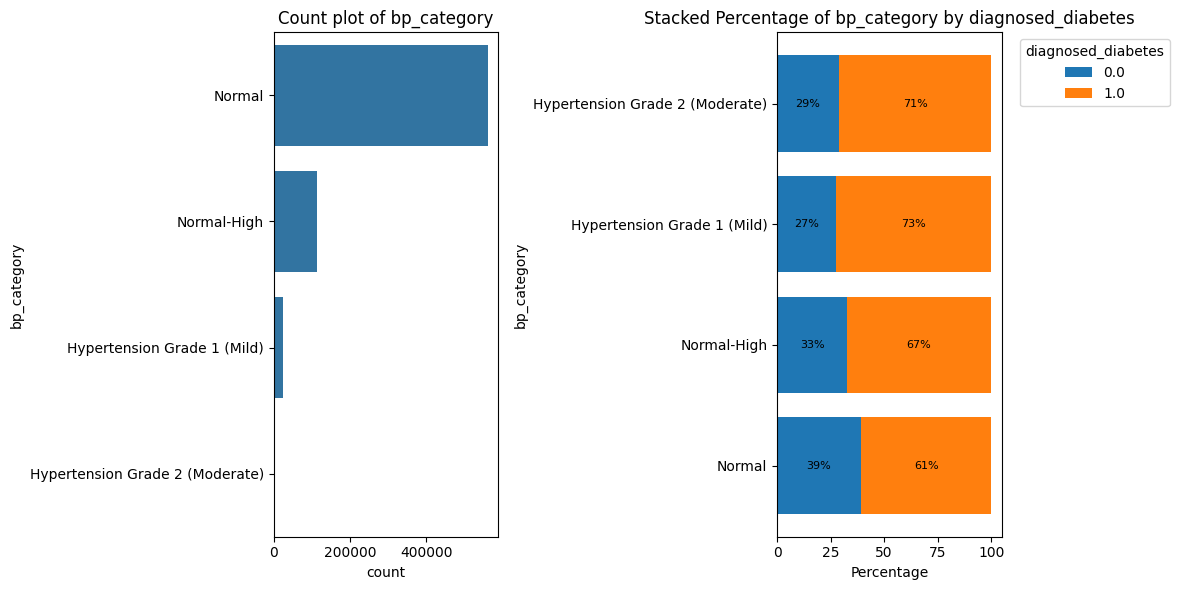

In [13]:
def bin_pressure(df):
    conditions = [
        # Grade 2 (Moderate)
        (df['systolic_bp'] >= 160) | (df['diastolic_bp'] >= 100),

        # Grade 1 (Mild)
        (df['systolic_bp'] >= 140) | (df['diastolic_bp'] >= 90),

        # Normal-High
        (df['systolic_bp'] >= 130) | (df['diastolic_bp'] >= 85),

        # Normal
        (df['systolic_bp'] < 130) & (df['diastolic_bp'] < 85)
    ]

    choices = [
        'Hypertension Grade 2 (Moderate)',
        'Hypertension Grade 1 (Mild)',
        'Normal-High',
        'Normal'
    ]

    df['bp_category'] = np.select(conditions, choices, default=None)

    # Ordered categorical WITHOUT Grade 3
    bp_order = [
        'Normal',
        'Normal-High',
        'Hypertension Grade 1 (Mild)',
        'Hypertension Grade 2 (Moderate)'
    ]

    df['bp_category'] = pd.Categorical(
        df['bp_category'],
        categories=bp_order,
        ordered=True
    )

    return df


train = bin_pressure(train)
test = bin_pressure(test)
plot_cat_vs_target_v2(train[['bp_category',target]], target, max_unique=20)

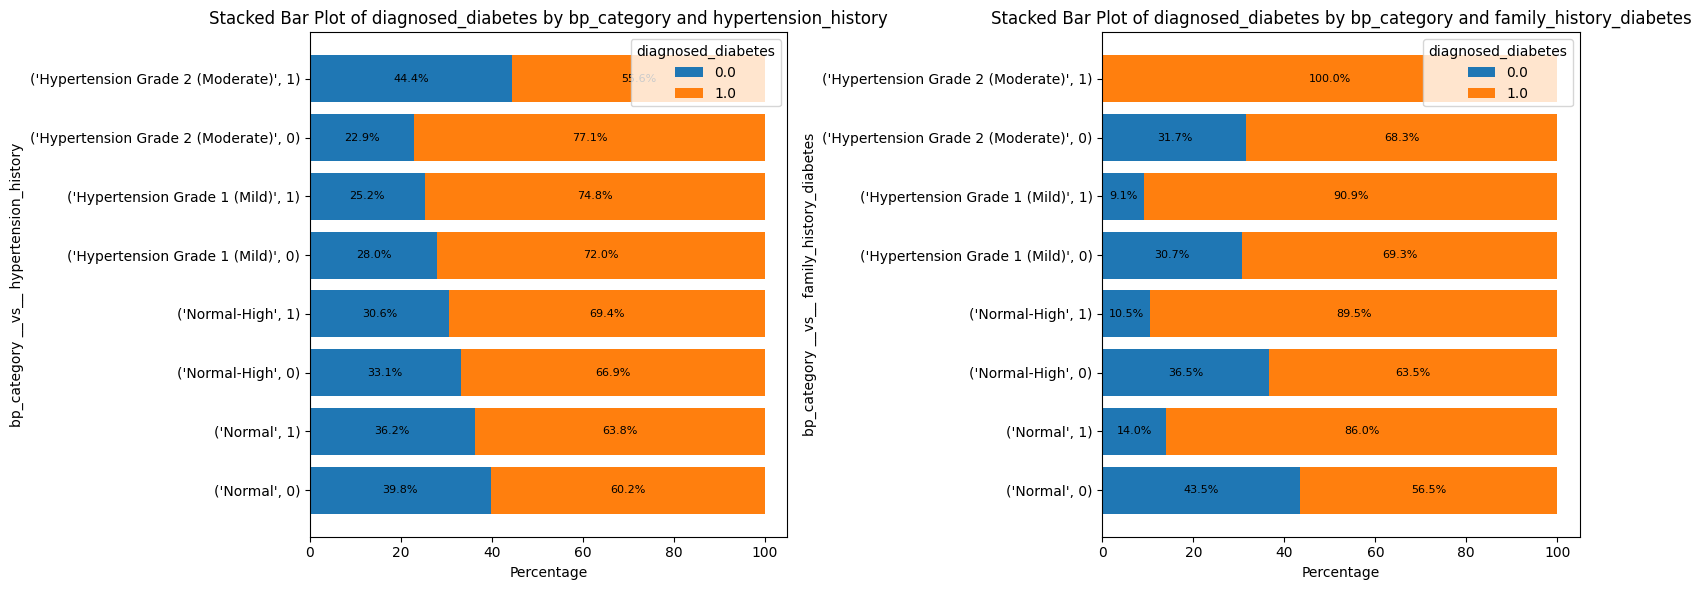

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

EDA_stacked_depression_v2(
    train,
    'bp_category',
    'family_history_diabetes',
    target,
    ax=ax[1])

EDA_stacked_depression_v2(
    train,
    'bp_category',
    'hypertension_history',
    target,
    ax=ax[0])

plt.tight_layout()
plt.show()

Hypertension can affect the likelihood of a patient developing diabetes. When we combine this with a history of hypertension, we can see that even if the patient didn’t have hypertension in the past, if their blood pressure reaches grade 1 or grade 2, the likelihood of developing diabetes remains high.
## Age:

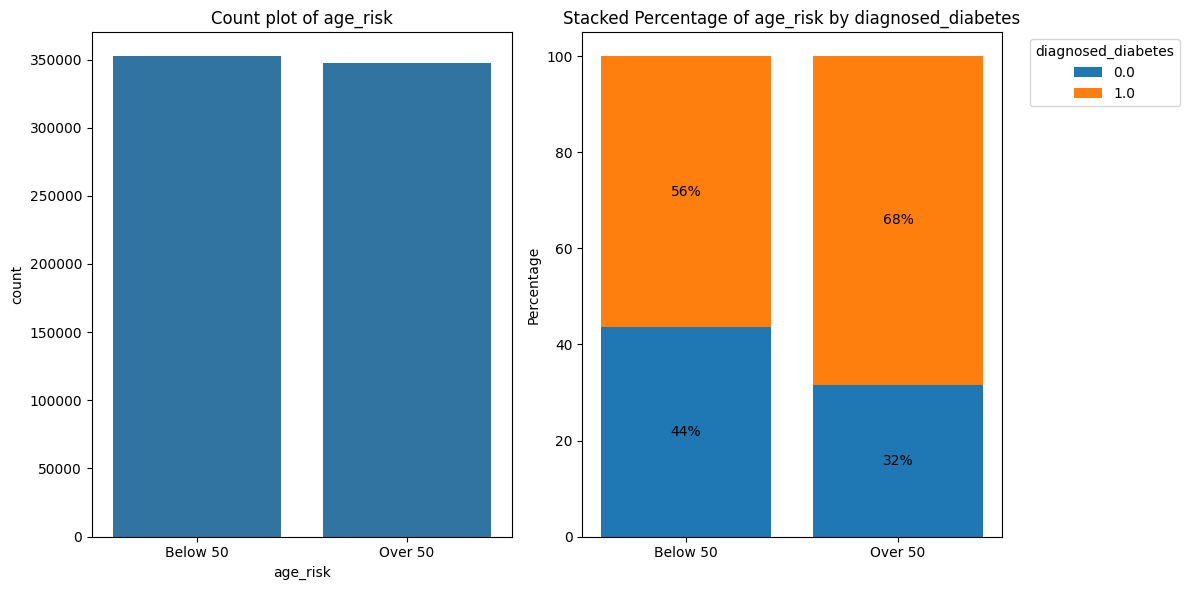

In [15]:
train['age_risk'] = train['age'].apply(lambda x: 'Over 50' if x > 50 else 'Below 50')
test['age_risk'] = test['age'].apply(lambda x: 'Over 50' if x > 50 else 'Below 50')
plot_cat_vs_target(train[['age_risk',target]], target, max_unique=20)

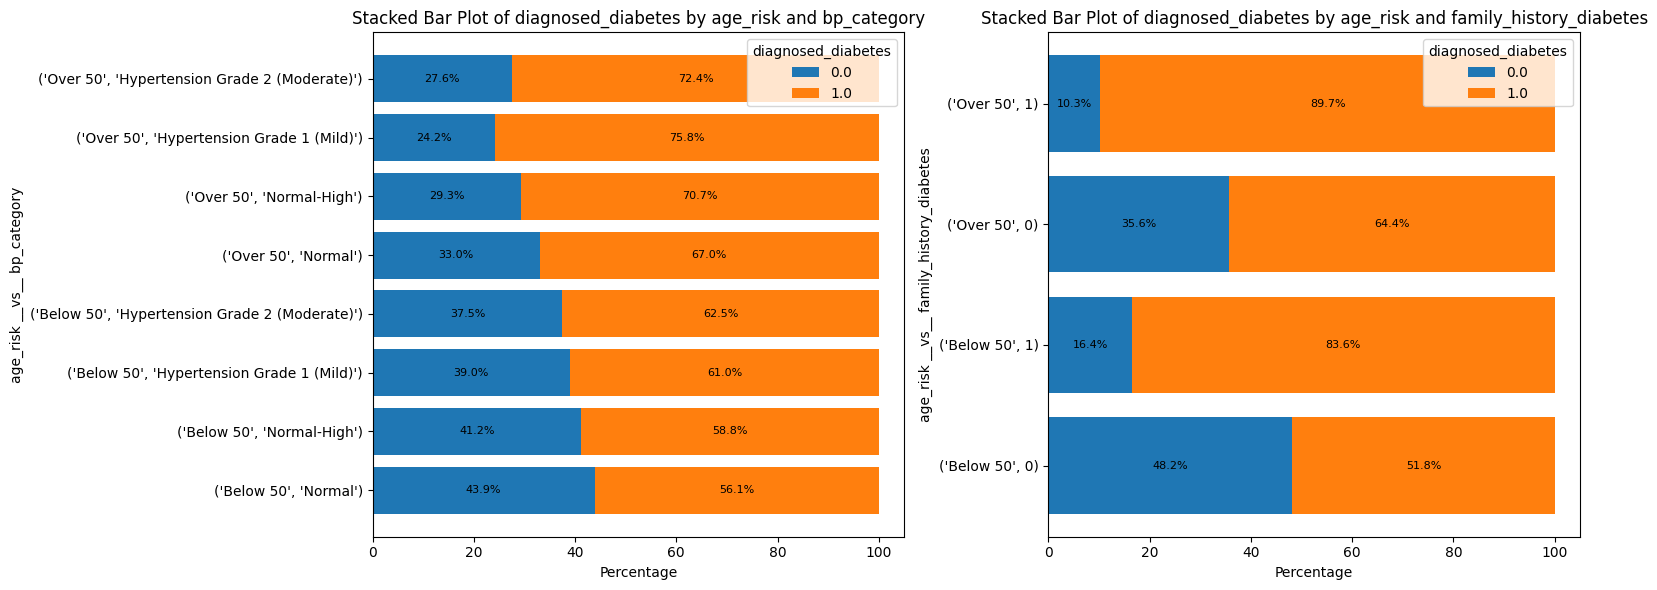

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

EDA_stacked_depression_v2(
    train,
    'age_risk','bp_category',
    target,
    ax=ax[0])

EDA_stacked_depression_v2(
    train,
    'age_risk','family_history_diabetes',
    target,
    ax=ax[1])

plt.tight_layout()
plt.show()

When we compare age with the likelihood of developing diabetes, we can clearly see a trend: the older the person, the higher the chance of developing diabetes.

## Physical Minutes per Week:

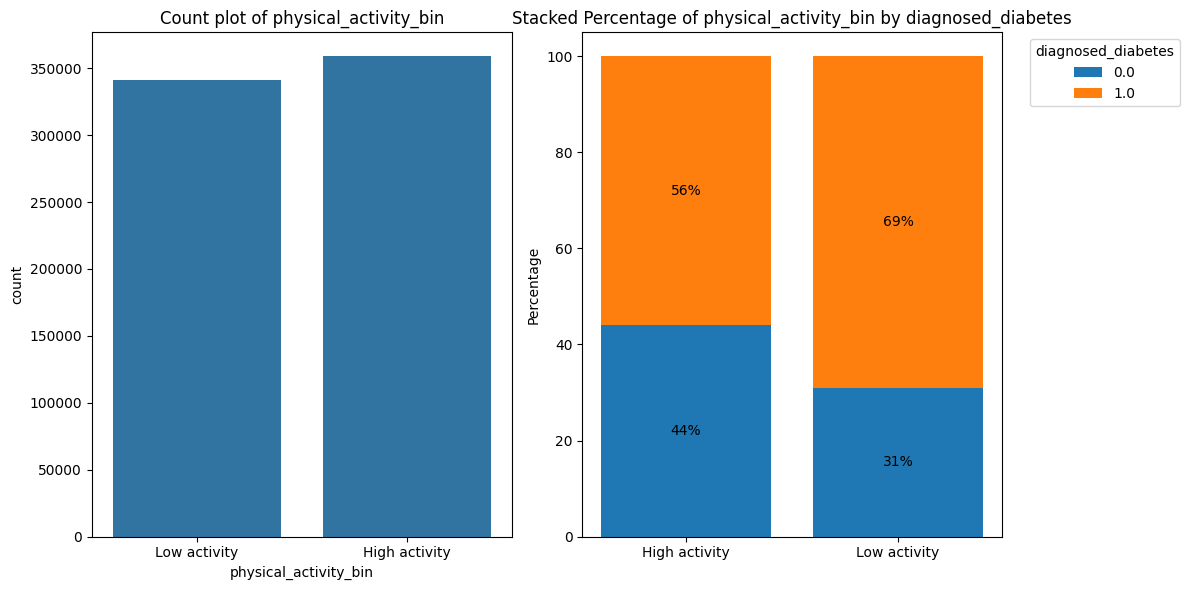

In [17]:
train['physical_activity_bin'] = train['physical_activity_minutes_per_week'].apply(
        lambda x: 'Low activity' if x < 70 else 'High activity')
test['physical_activity_bin'] = test['physical_activity_minutes_per_week'].apply(
        lambda x: 'Low activity' if x < 70 else 'High activity')
plot_cat_vs_target(train[['physical_activity_bin',target]], target, max_unique=20)

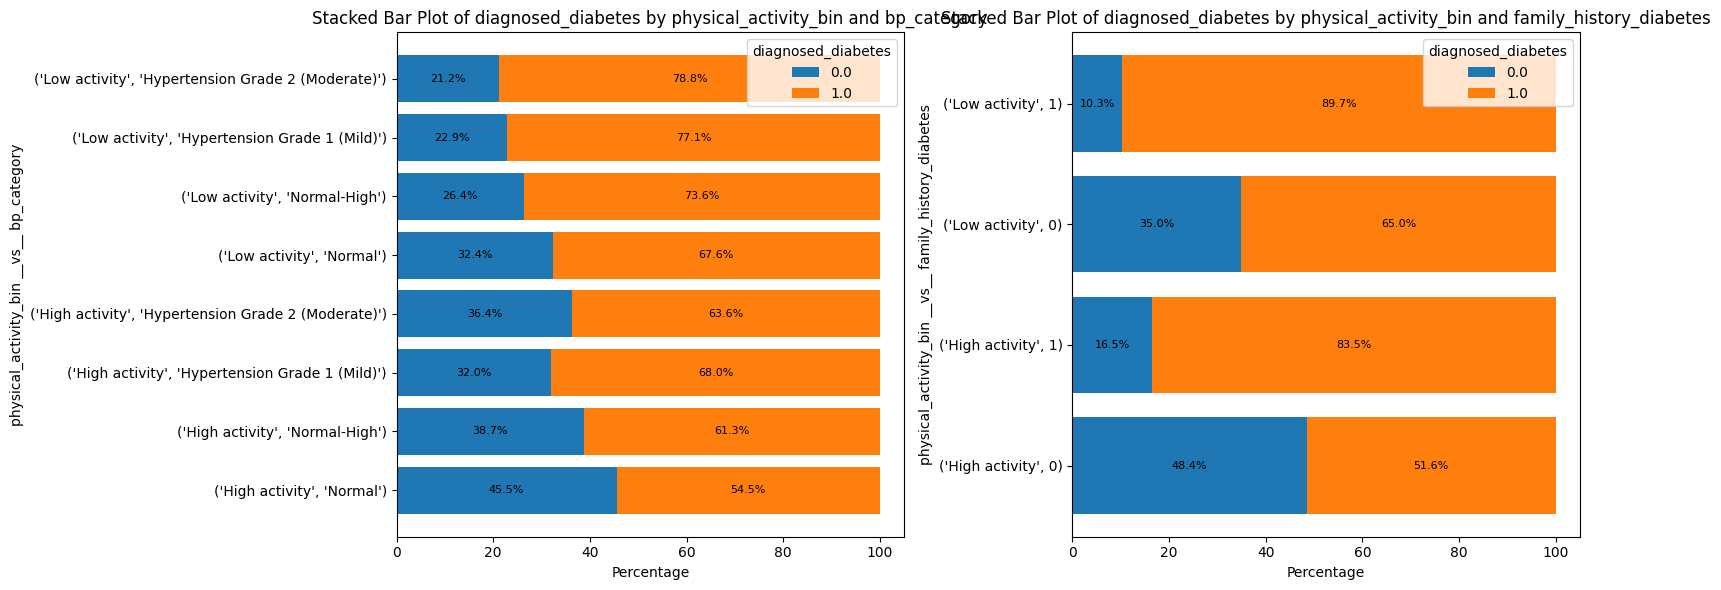

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

EDA_stacked_depression_v2(
    train,
    'physical_activity_bin','bp_category',
    target,
    ax=ax[0])

EDA_stacked_depression_v2(
    train,
    'physical_activity_bin','family_history_diabetes',
    target,
    ax=ax[1])

plt.tight_layout()
plt.show()


## Diet Score:

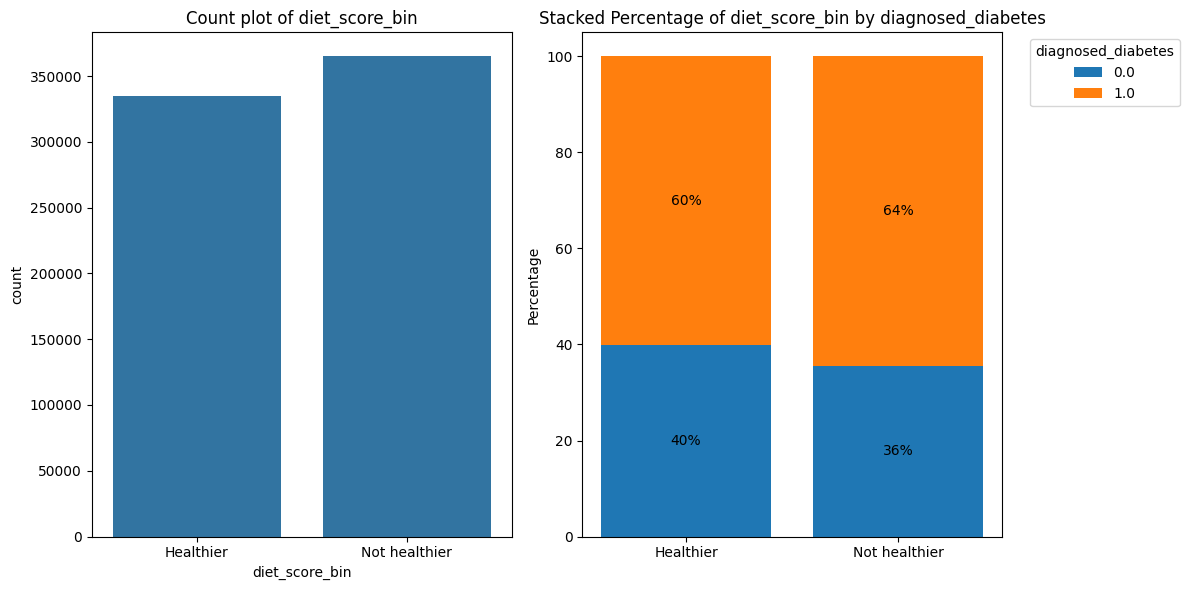

In [19]:
train['diet_score_bin'] = train['diet_score'].apply(lambda x: 'Healthier' if x > 6 else 'Not healthier')
test['diet_score_bin'] = test['diet_score'].apply(lambda x: 'Healthier' if x > 6 else 'Not healthier')
plot_cat_vs_target(train[['diet_score_bin',target]], target, max_unique=20)

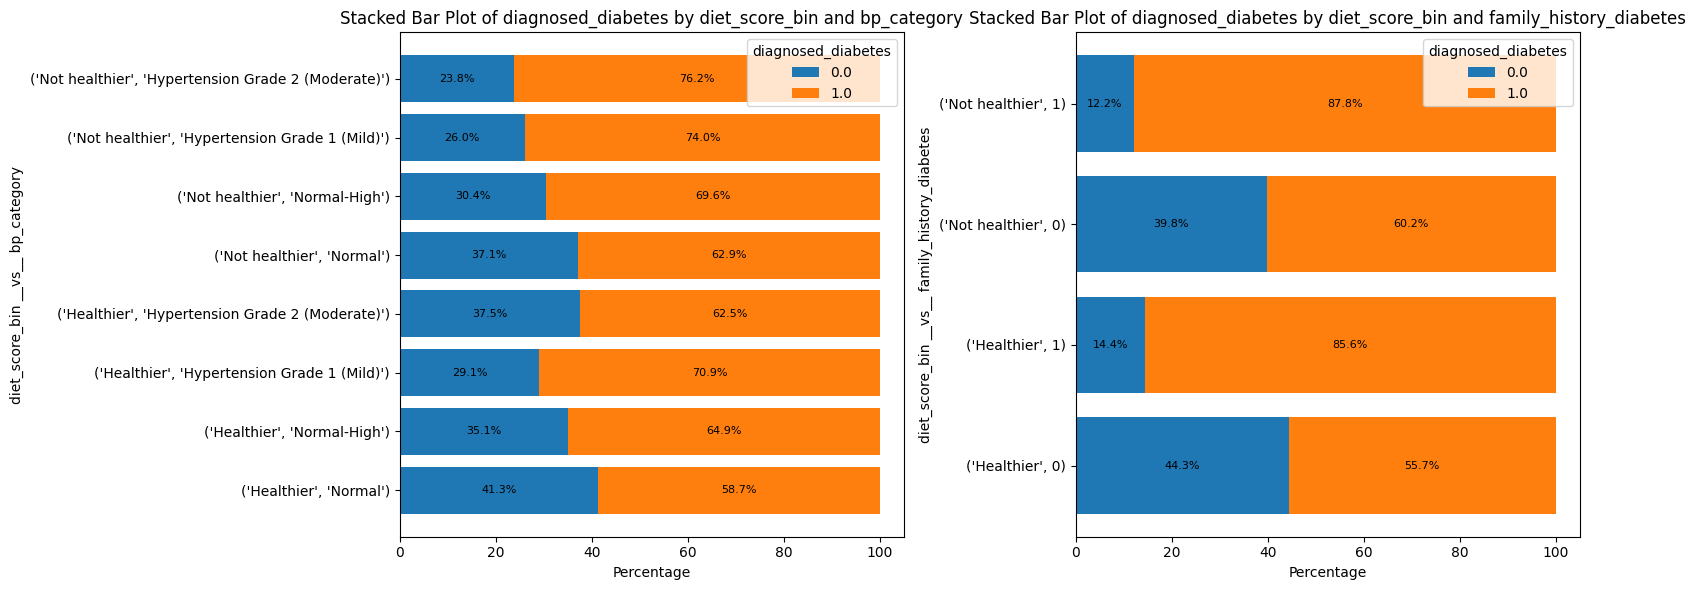

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

EDA_stacked_depression_v2(
    train,
    'diet_score_bin','bp_category',
    target,
    ax=ax[0])

EDA_stacked_depression_v2(
    train,
    'diet_score_bin','family_history_diabetes',
    target,
    ax=ax[1])

plt.tight_layout()
plt.show()

## Cholesterol:

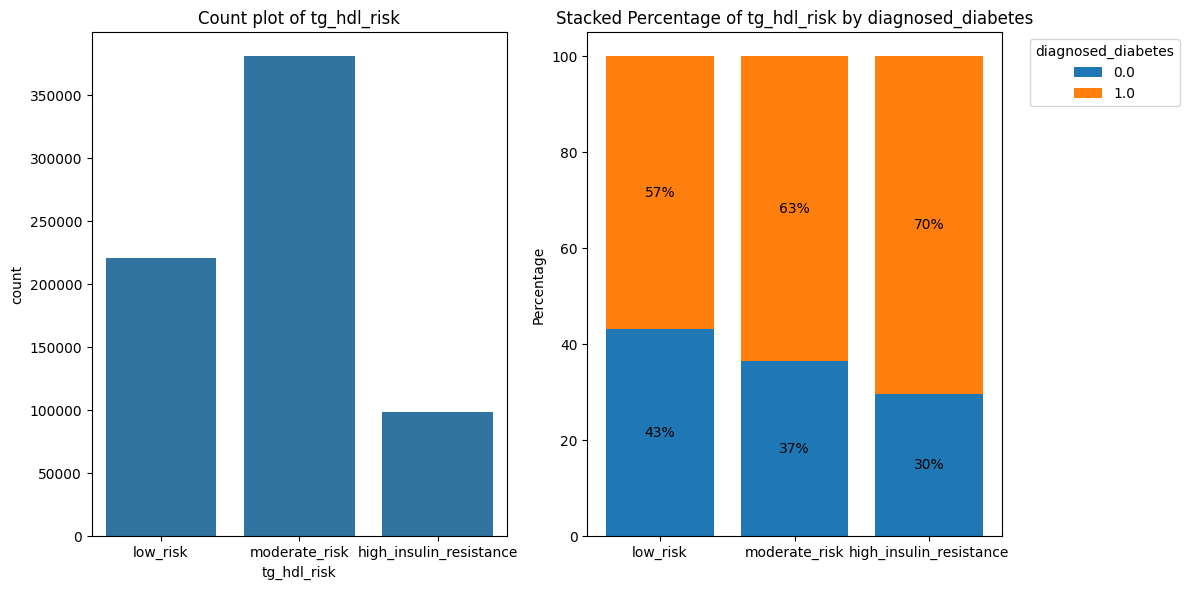

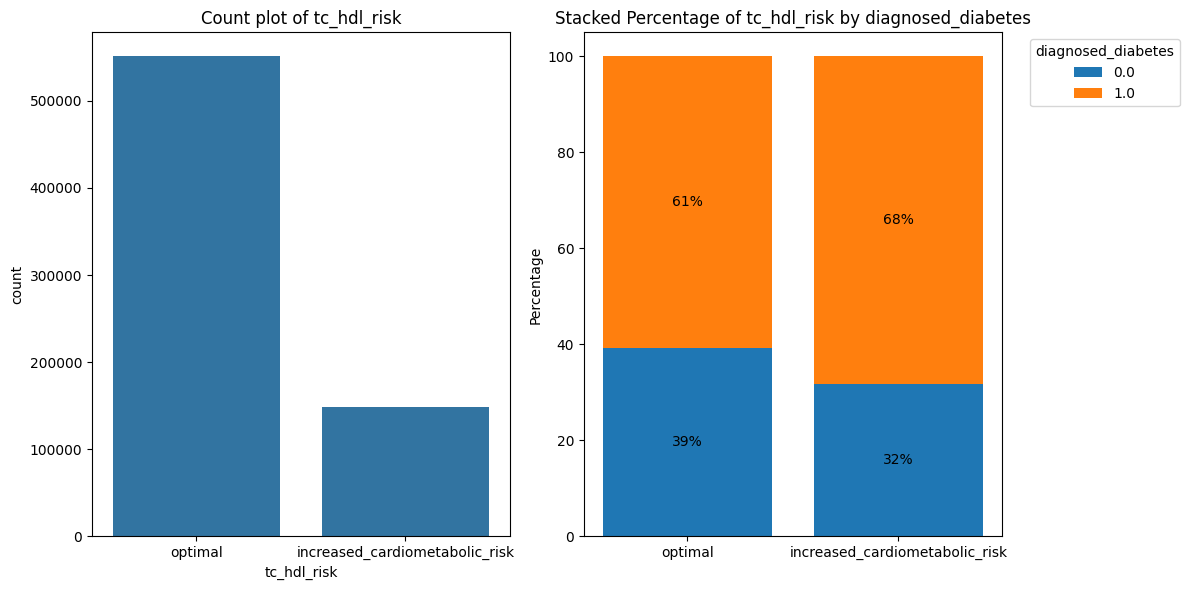

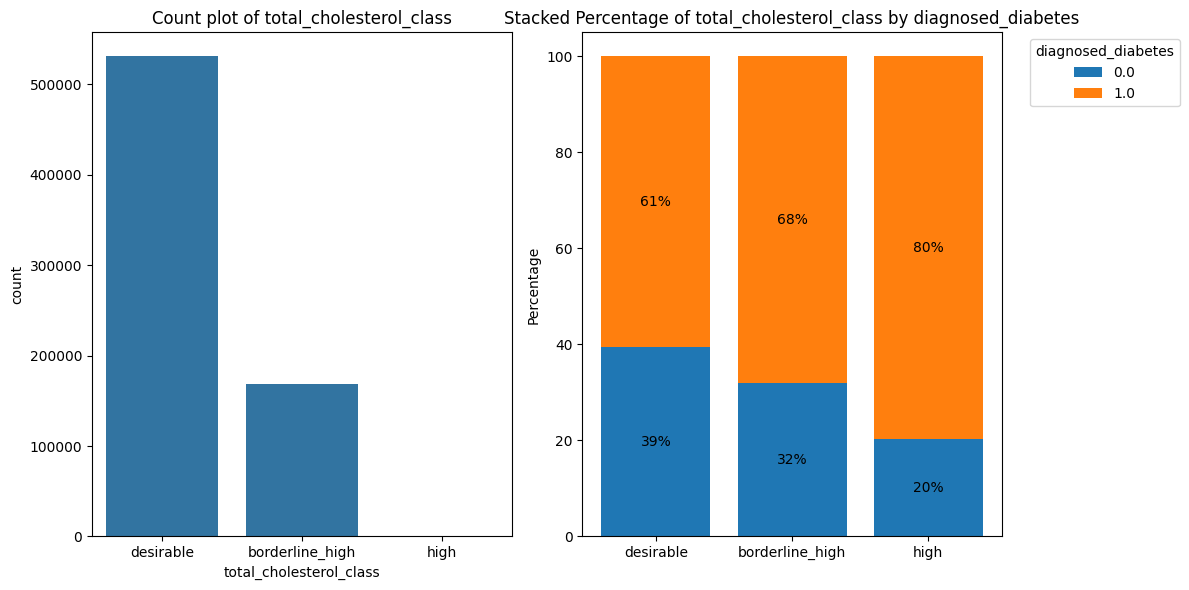

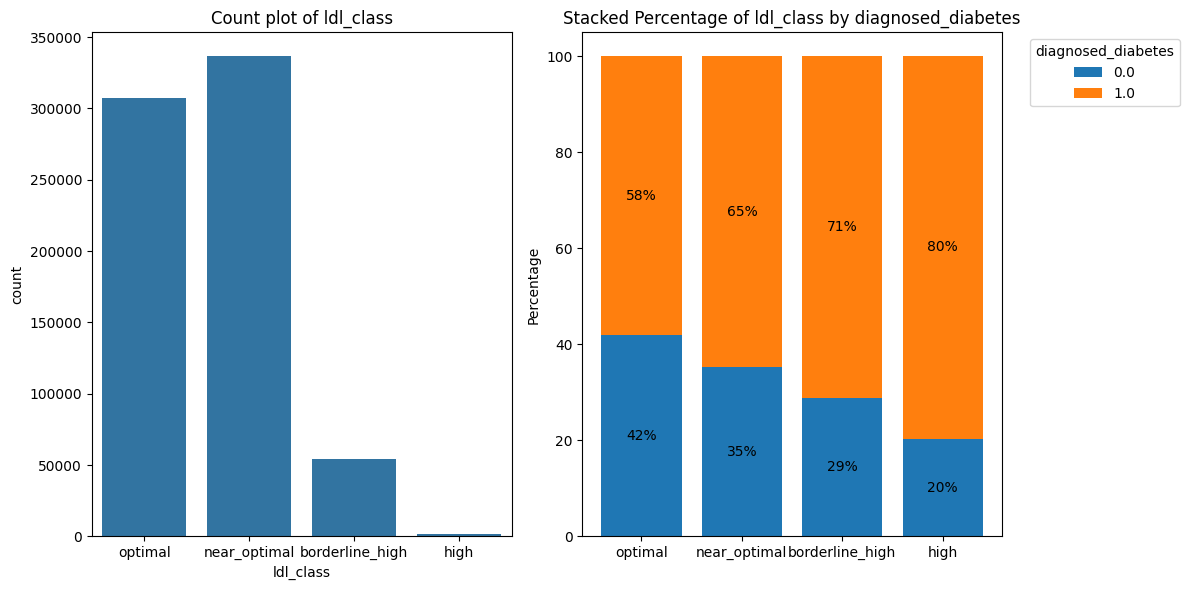

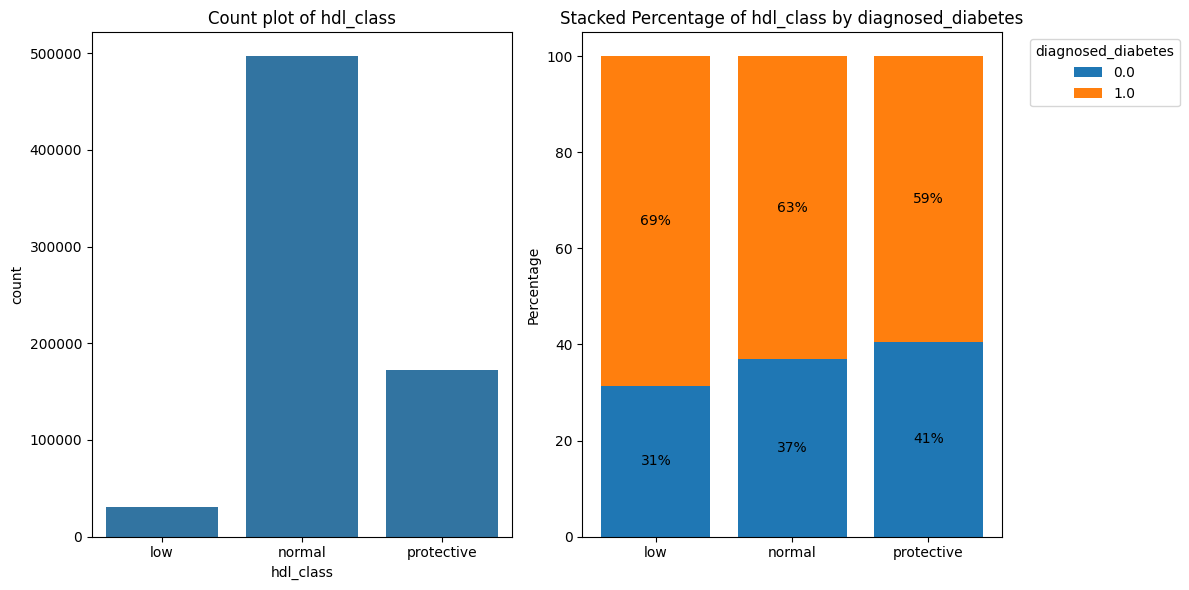

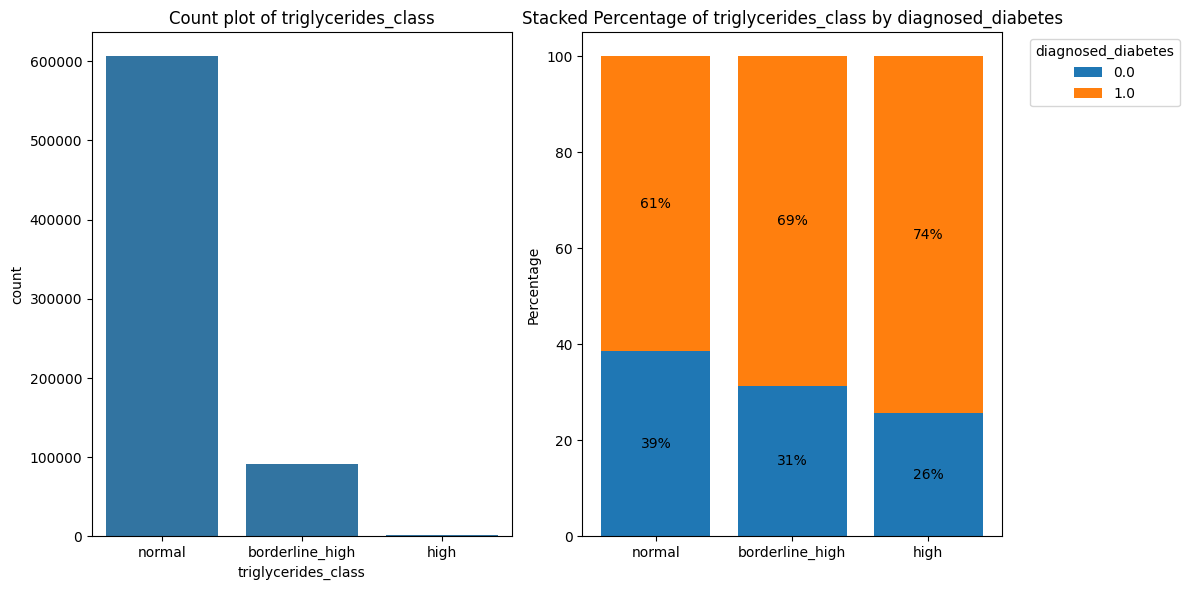

In [21]:
def calculate_ratio(df):
    df["tg_hdl_risk"] = df["triglycerides"] / df["hdl_cholesterol"].replace(0, np.nan)
    df["tc_hdl_risk"] = df["cholesterol_total"] / df["hdl_cholesterol"].replace(0, np.nan)
    df["tg_hdl_risk"] = pd.cut(
        df["tg_hdl_risk"],
        bins=[-np.inf, 2, 3, np.inf],
        labels=["low_risk", "moderate_risk", "high_insulin_resistance"])

    df["tc_hdl_risk"] = pd.cut(
        df["tc_hdl_risk"],
        bins=[-np.inf, 4, np.inf],
        labels=["optimal", "increased_cardiometabolic_risk"])
    # Total Cholesterol
    df["total_cholesterol_class"] = pd.cut(
        df["cholesterol_total"],
        bins=[-float("inf"), 199, 239, float("inf")],
        labels=["desirable", "borderline_high", "high"])

    # LDL Cholesterol
    df["ldl_class"] = pd.cut(
        df["ldl_cholesterol"],
        bins=[-float("inf"), 99, 129, 159, float("inf")],
        labels=["optimal", "near_optimal", "borderline_high", "high"])

    # HDL Cholesterol
    df["hdl_class"] = pd.cut(
        df["hdl_cholesterol"],
        bins=[-float("inf"), 39, 59, float("inf")],
        labels=["low", "normal", "protective"])

    # Triglycerides
    df["triglycerides_class"] = pd.cut(
    df["triglycerides"],
    bins=[-float("inf"), 149, 199, float("inf")],
    labels=["normal", "borderline_high", "high"])    
    return df
    
train = calculate_ratio(train)
test = calculate_ratio(test)
plot_cat_vs_target(train[['tg_hdl_risk', 'tc_hdl_risk',
       'total_cholesterol_class', 'ldl_class', 'hdl_class',
       'triglycerides_class',target]], target, max_unique=20)

In [22]:
train.to_csv('../Data/train_processed.csv',index=False)
test.to_csv('../Data/test_processed.csv',index=False)